# EDA – Real Load Data (Final dataset)

Real household data with solar panels + home battery (SOFAR ME3000SP).

**Main file:** `Data/real_load/Final/overall_verrijkt.csv`  
**Period:** 2024-11-01 → 2026-04-06 (~17 months, 15-minute resolution)

---

### Key columns

**Grid flows (kWh per 15-min)**
| Column | Meaning |
|---|---|
| `afname_kwh` | Grid import — energy taken from the grid |
| `injectie_kwh` | Grid export — solar surplus injected to the grid |
| `verbruik_kwh` | Total household consumption (all sources combined) |
| `fl_afname_dag` | Grid import during *dag* tariff period |
| `fl_afname_nacht` | Grid import during *nacht* tariff period |
| `fl_injectie_dag` | Grid export during *dag* tariff period |
| `fl_injectie_nacht` | Grid export during *nacht* tariff period |

**Solar (kWh per 15-min)**
| Column | Meaning |
|---|---|
| `sl_productie_kwh` | Solar production — **all zeros in raw file**, derived in Section 2 from energy balance |

**Battery (kWh per 15-min)**
| Column | Meaning |
|---|---|
| `bat_laden_kwh_kw` | Battery charge energy — energy flowing **into** the battery |
| `bat_ontladen_kwh_kw` | Battery discharge energy — energy flowing **out** of the battery |
| `bat_geladen_kwh` | **SOC change in percentage points** (integers: −1, 0, 1, 2 …) — NOT kWh |
| `soc_begin` / `soc_eind` | Battery state of charge % at start / end of 15-min slot *(only Jan–Apr 2026)* |

**Instantaneous power (kW, averaged over 15-min)**
| Column | Meaning |
|---|---|
| `afname_kw` | Grid import power |
| `terugave_kw` | Grid export power |
| `bat_laden_kw` | Battery charge power *(only Jan–Apr 2026)* |
| `bat_ontladen_kw` | Battery discharge power *(only Jan–Apr 2026)* |

**Other**
| Column | Meaning |
|---|---|
| `tarief` | Electricity tariff period: `dag` or `nacht` |
| `weer_poa_w_m2` | Solar irradiance on panel surface (W/m²) |


## 1. Load data

In [153]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams["figure.dpi"] = 120

DATA_FILE = os.path.join("..", "..", "Data", "real_load", "Final", "overall_verrijkt.csv")

df = pd.read_csv(DATA_FILE, parse_dates=["kwartier"], index_col="kwartier")
df = df.sort_index()

print(f"Rows:       {len(df):,}")
print(f"Date range: {df.index.min()} → {df.index.max()}")
print(f"Columns:    {list(df.columns)}")


Rows:       50,104
Date range: 2024-11-01 00:00:00 → 2026-04-06 23:45:00
Columns:    ['afname_kwh', 'injectie_kwh', 'tarief', 'fl_afname_dag', 'fl_afname_nacht', 'fl_injectie_dag', 'fl_injectie_nacht', 'bat_laden_kw', 'bat_ontladen_kw', 'afname_kw', 'terugave_kw', 'soc_begin', 'soc_eind', 'n_seconden', 'sl_afname_kwh', 'sl_injectie_kwh', 'sl_productie_kwh', 'bat_geladen_kwh', 'bat_ontladen_kwh', 'bat_soc_uur', 'weer_poa_w_m2', 'weer_ghi_w_m2', 'weer_zon_min', 'ev_energie_kwh', 'ev_vermogen_kw', 'ev_kwh', 'bat_ontladen_kwh_kw', 'bat_laden_kwh_kw', 'verbruik_kwh']


In [154]:
# Missing values per column
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Missing values:")
print(missing)
print()
df.describe().round(3)


Missing values:
bat_laden_kw        48534
bat_ontladen_kw     48534
afname_kw           48534
terugave_kw         48534
soc_begin           48534
soc_eind            48534
n_seconden          48534
bat_geladen_kwh      3728
bat_ontladen_kwh     3728
bat_soc_uur          3728
ev_energie_kwh      44375
ev_vermogen_kw      44375
dtype: int64



,afname_kwh,injectie_kwh,fl_afname_dag,fl_afname_nacht,fl_injectie_dag,fl_injectie_nacht,bat_laden_kw,bat_ontladen_kw,afname_kw,terugave_kw,...,bat_soc_uur,weer_poa_w_m2,weer_ghi_w_m2,weer_zon_min,ev_energie_kwh,ev_vermogen_kw,ev_kwh,bat_ontladen_kwh_kw,bat_laden_kwh_kw,verbruik_kwh
count,50104.000,50104.000,50104.000,50104.000,50104.000,50104.000,1570.000,1570.000,1570.000,1570.000,...,46376.000,50104.000,50104.000,50104.000,5729.000,5729.000,50104.000,50104.000,50104.000,50104.000
mean,0.231,0.005,0.069,0.162,0.004,0.002,0.144,0.122,0.946,0.018,...,18.622,99.234,118.082,17.506,0.604,2.411,0.069,0.037,0.040,0.178
std,0.269,0.023,0.161,0.262,0.018,0.014,0.398,0.339,0.943,0.040,...,31.248,201.075,194.795,26.493,0.232,0.930,0.208,0.103,0.112,0.164
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.002,0.007,0.000,0.000,-0.250,0.000
25%,0.025,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.375,0.000,...,0.000,0.000,0.000,0.000,0.495,1.979,0.000,0.000,0.000,0.067
50%,0.138,0.000,0.000,0.008,0.000,0.000,0.000,0.000,0.640,0.000,...,0.000,0.000,0.000,0.000,0.560,2.238,0.000,0.000,0.000,0.145
75%,0.301,0.001,0.041,0.198,0.000,0.000,0.046,0.011,1.184,0.001,...,25.000,77.700,165.000,60.000,0.671,2.685,0.000,0.000,0.000,0.250
max,2.080,0.638,1.779,2.080,0.638,0.616,2.364,2.429,5.343,0.362,...,100.000,923.520,889.000,60.000,3.262,13.047,3.262,1.000,2.000,1.604


## 2. Derive solar production from energy balance

`sl_productie_kwh` is all zeros in the dataset — not measured directly.  
We reconstruct it from the energy balance:

```
solar = verbruik + injectie + bat_laden_kwh_kw - bat_ontladen_kwh_kw - afname
```

Note: `ev_energie_kwh` is excluded from the formula — EV sessions are recorded
as a lump sum per charging session (not per 15-min slot), so including EV
creates false solar peaks at night. Negative values from battery round-trip
losses (~6%) are clipped to zero.


In [155]:
# Derive solar at 15-min level from energy balance
# Clip bat_laden to physical limits before the formula:
#   glitch -0.250 kWh on 2025-03-14 (impossible negative charge)
#   glitch +2.000 kWh on 2025-02-10 (max = 3 kW x 0.25 h = 0.75 kWh)
bat_laden_clipped = df["bat_laden_kwh_kw"].clip(lower=0, upper=0.75)

solar_neg = (
    df["verbruik_kwh"] + df["injectie_kwh"]
    + bat_laden_clipped - df["bat_ontladen_kwh_kw"]
    - df["afname_kwh"]
)
solar_raw = solar_neg  # alias for cells below

solar_clipped = solar_neg.clip(lower=0)

# Zero out solar when irradiance sensor reads 0 (night / fully overcast)
solar_clipped = solar_clipped.where(df["weer_poa_w_m2"] > 0, 0.0)

df["sl_productie_kwh"] = solar_clipped.where(solar_clipped > 0.001, 0.0)

print(f"Before clip - negative rows: {(solar_neg < -0.001).sum():,}  "
      f"({(solar_neg < -0.001).sum()/len(df)*100:.1f}%)")
print(f"Energy lost by clipping:     {solar_neg[solar_neg < 0].sum():.1f} kWh total")
print(f"Non-zero solar rows:         {(df['sl_productie_kwh'] > 0.001).sum():,}")
print(f"Peak solar per 15-min:       {df['sl_productie_kwh'].max():.3f} kWh  "
      f"(= {df['sl_productie_kwh'].max()*4:.2f} kW)")

Before clip - negative rows: 5,672  (11.3%)
Energy lost by clipping:     -3284.7 kWh total
Non-zero solar rows:         5,495
Peak solar per 15-min:       0.763 kWh  (= 3.05 kW)


Negative values — summary (kWh per 15-min):
  Count:   8,008  (16.0% of all rows)
  Min:     -1.3190 kWh  (= -5.276 kW)
  Mean:    -0.4102 kWh
  Median:  -0.4956 kWh
  p5:      -0.9674 kWh
  p1:      -1.1350 kWh

Expected range from battery round-trip loss (~5%):
  Max charge per slot: 2.000 kWh  → 5% loss = 0.1000 kWh


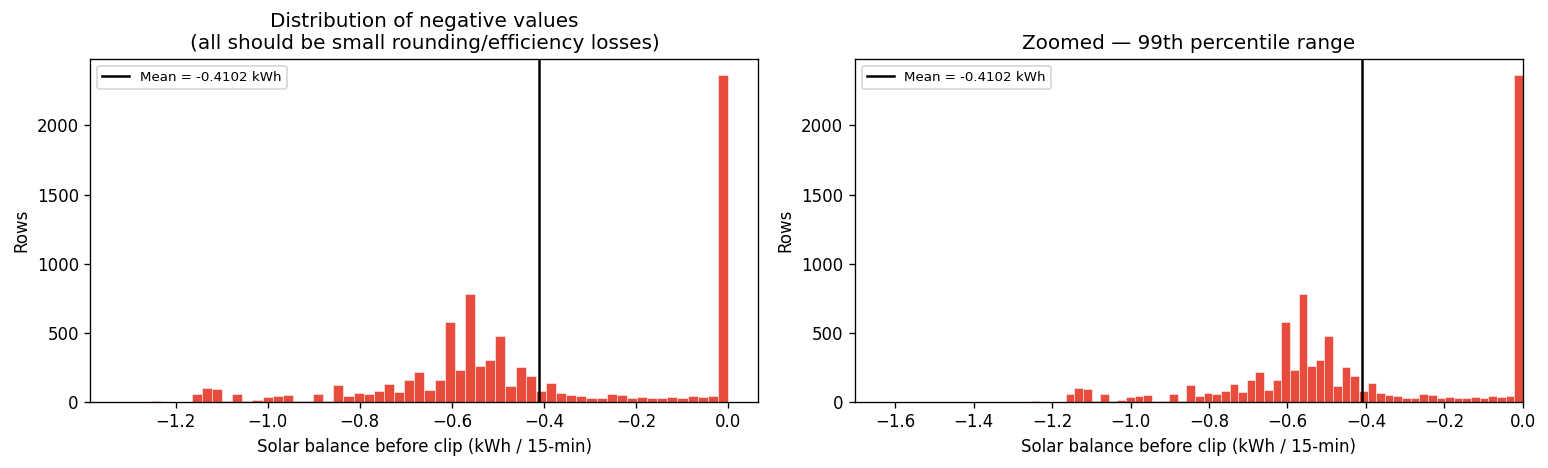


Suspiciously large negatives (< -0.5 kWh = < -2 kW equivalent):
  3911 rows — check if data gaps or meter errors!
kwartier
2025-03-02 05:30:00   -1.3190
2025-03-02 05:45:00   -1.2630
2025-03-02 06:00:00   -1.2370
2025-03-02 05:15:00   -1.2330
2025-03-02 06:15:00   -1.2310
2025-02-23 02:00:00   -1.1461
2025-02-23 02:15:00   -1.1461
2025-02-23 02:30:00   -1.1461
2025-02-23 03:30:00   -1.1461
2025-02-23 02:45:00   -1.1461
dtype: float64


In [156]:
# How large are the negative values before clipping?
neg = solar_neg[solar_neg < 0]

print(f"Negative values — summary (kWh per 15-min):")
print(f"  Count:   {len(neg):,}  ({len(neg)/len(df)*100:.1f}% of all rows)")
print(f"  Min:     {neg.min():.4f} kWh  (= {neg.min()*4:.3f} kW)")
print(f"  Mean:    {neg.mean():.4f} kWh")
print(f"  Median:  {neg.median():.4f} kWh")
print(f"  p5:      {neg.quantile(0.05):.4f} kWh")
print(f"  p1:      {neg.quantile(0.01):.4f} kWh")
print(f"\nExpected range from battery round-trip loss (~5%):")
print(f"  Max charge per slot: {df['bat_laden_kwh_kw'].max():.3f} kWh  → 5% loss = {df['bat_laden_kwh_kw'].max()*0.05:.4f} kWh")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(neg, bins=60, color="#e74c3c", edgecolor="white", lw=0.3)
ax.axvline(neg.mean(), color="black", lw=1.5, label=f"Mean = {neg.mean():.4f} kWh")
ax.set_xlabel("Solar balance before clip (kWh / 15-min)")
ax.set_ylabel("Rows")
ax.set_title("Distribution of negative values\n(all should be small rounding/efficiency losses)")
ax.legend(fontsize=8)

ax = axes[1]
ax.hist(neg, bins=60, color="#e74c3c", edgecolor="white", lw=0.3)
ax.set_xlim(neg.quantile(0.01) * 1.5, 0)  # zoom in: ignore extreme outliers
ax.axvline(neg.mean(), color="black", lw=1.5, label=f"Mean = {neg.mean():.4f} kWh")
ax.set_xlabel("Solar balance before clip (kWh / 15-min)")
ax.set_ylabel("Rows")
ax.set_title("Zoomed — 99th percentile range")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Flag suspiciously large negatives (more than 0.5 kWh = 2 kW over 15 min)
threshold = -0.5
large_neg = solar_neg[solar_neg < threshold]
print(f"\nSuspiciously large negatives (< {threshold} kWh = < {threshold*4:.0f} kW equivalent):")
if len(large_neg) == 0:
    print("  None — all negatives are within expected battery loss range.")
else:
    print(f"  {len(large_neg)} rows — check if data gaps or meter errors!")
    print(large_neg.sort_values().head(10))


In [157]:
# Diagnose: is bat_laden_kwh_kw in kWh or in kW?
# For a 15-min slot: energy (kWh) = power (kW) × (15/60) = power × 0.25
# If the column is kWh: bat_laden_kwh_kw ≈ bat_laden_kw × 0.25
# If the column is kW:  bat_laden_kwh_kw ≈ bat_laden_kw  (same value, wrong unit)

# Compare the two columns on slots where battery is actively charging
charging = df[(df["bat_laden_kwh_kw"] > 0.01) & df["bat_laden_kw"].notna()].copy()
charging["ratio"] = charging["bat_laden_kwh_kw"] / charging["bat_laden_kw"]

print("bat_laden_kwh_kw  vs  bat_laden_kw — ratio (should be ~0.25 if kwh_kw is in kWh):")
print(charging["ratio"].describe().round(4))
print()
print("Sample rows (first 10 charging slots with both columns present):")
print(charging[["bat_laden_kwh_kw", "bat_laden_kw", "ratio"]].head(10).round(4))


bat_laden_kwh_kw  vs  bat_laden_kw — ratio (should be ~0.25 if kwh_kw is in kWh):
count    438.00
mean       0.25
std        0.00
min        0.25
25%        0.25
50%        0.25
75%        0.25
max        0.25
Name: ratio, dtype: float64

Sample rows (first 10 charging slots with both columns present):
                     bat_laden_kwh_kw  bat_laden_kw  ratio
kwartier                                                  
2026-01-21 12:00:00            0.0248        0.0990   0.25
2026-01-21 13:45:00            0.0120        0.0479   0.25
2026-01-21 14:00:00            0.0345        0.1380   0.25
2026-01-22 04:30:00            0.0232        0.0927   0.25
2026-01-22 11:15:00            0.0238        0.0954   0.25
2026-01-22 11:45:00            0.0696        0.2784   0.25
2026-01-22 13:00:00            0.0286        0.1142   0.25
2026-01-22 13:15:00            0.0902        0.3608   0.25
2026-01-22 13:30:00            0.0282        0.1128   0.25
2026-01-22 13:45:00            0.0946        0.

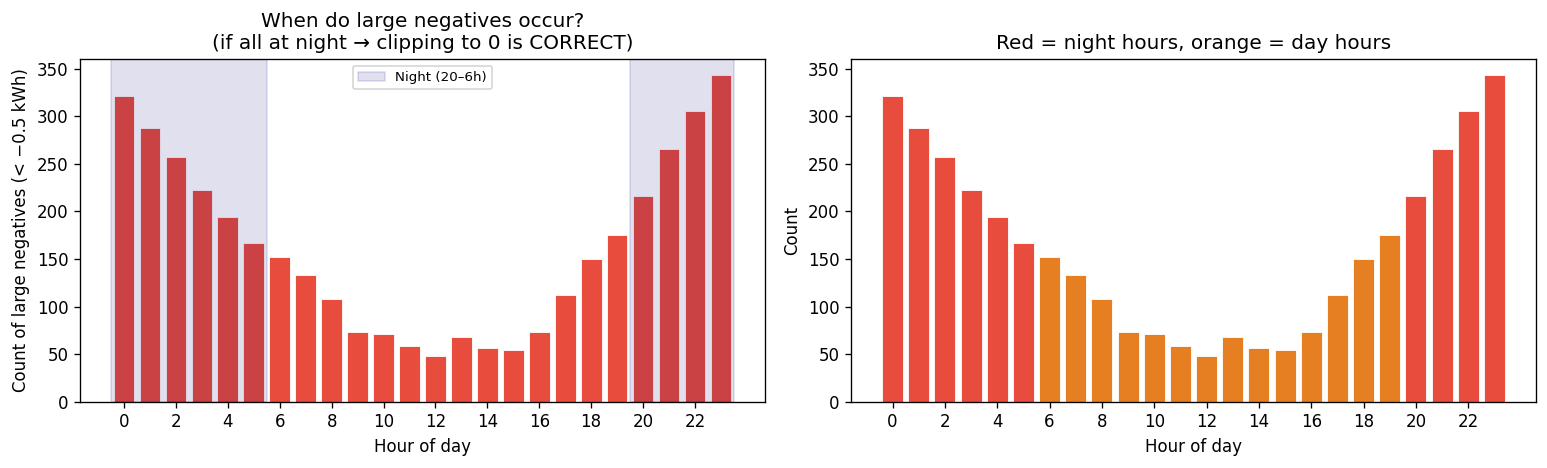

Large negatives at NIGHT (20–6h):   2,580  (66.0%)
Large negatives during DAY (6–20h): 1,331  (34.0%)

Day-time large negatives (potential real problem):
kwartier
2025-03-02 06:00:00   -1.2370
2025-03-02 06:15:00   -1.2310
2025-02-09 06:15:00   -1.1454
2025-02-23 11:45:00   -1.1407
2025-02-23 12:00:00   -1.1407
2025-02-23 12:15:00   -1.1407
2025-02-23 12:30:00   -1.1407
2025-02-23 12:45:00   -1.1407
2025-02-09 07:45:00   -1.1367
2025-02-09 07:30:00   -1.1367
dtype: float64


In [158]:
# When (hour of day) do the large negatives occur?
large_neg_rows = solar_neg[solar_neg < -0.5]
large_neg_hours = large_neg_rows.index.hour

counts = large_neg_hours.value_counts().reindex(range(24), fill_value=0).sort_index()
colors = ["#e74c3c" if (h < 6 or h >= 20) else "#e67e22" for h in range(24)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.bar(counts.index, counts.values, color="#e74c3c", edgecolor="white", linewidth=0.5)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Count of large negatives (< −0.5 kWh)")
ax.set_title("When do large negatives occur?\n(if all at night → clipping to 0 is CORRECT)")
ax.set_xticks(range(0, 24, 2))
ax.axvspan(-0.5, 5.5,  alpha=0.12, color="navy")
ax.axvspan(19.5, 23.5, alpha=0.12, color="navy", label="Night (20–6h)")
ax.legend(fontsize=8)

ax = axes[1]
ax.bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Count")
ax.set_title("Red = night hours, orange = day hours")
ax.set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

# night_mask aligns with large_neg_rows (both shape 3911)
night_mask = (large_neg_hours < 6) | (large_neg_hours >= 20)
n_night = night_mask.sum()
n_day   = (~night_mask).sum()
print(f"Large negatives at NIGHT (20–6h):   {n_night:,}  ({n_night/len(large_neg_rows)*100:.1f}%)")
print(f"Large negatives during DAY (6–20h): {n_day:,}  ({n_day/len(large_neg_rows)*100:.1f}%)")
print()
if n_day == 0:
    print("All large negatives are at night → clipping to 0 is CORRECT (no solar at night).")
    print("The formula gives large negatives only when the battery is active at night,")
    print("but since true solar = 0 at night, clip(0) gives the right answer.")
else:
    day_neg = large_neg_rows[~night_mask]
    print("Day-time large negatives (potential real problem):")
    print(day_neg.sort_values().head(10))


In [159]:
# Better check: use actual irradiance (weer_poa_w_m2) as "is it really daylight?"
# A fixed 6-20h window is wrong in winter (sunrise ~8:45 in December)
large_neg_df = df.loc[large_neg_rows.index, ["weer_poa_w_m2"]].copy()
large_neg_df["solar_neg_kwh"] = large_neg_rows
large_neg_df["hour"]  = large_neg_df.index.hour
large_neg_df["month"] = large_neg_df.index.month

# Real daylight: irradiance > 0 W/m²
real_daylight = large_neg_df["weer_poa_w_m2"] > 0
n_real_day = real_daylight.sum()
n_dark     = (~real_daylight).sum()

print(f"Large negatives when irradiance > 0 (real daylight): {n_real_day:,}  ({n_real_day/len(large_neg_df)*100:.1f}%)")
print(f"Large negatives when irradiance = 0 (dark):          {n_dark:,}  ({n_dark/len(large_neg_df)*100:.1f}%)")

if n_real_day > 0:
    print(f"\nDaylight large negatives — month distribution:")
    print(large_neg_df[real_daylight]["month"].value_counts().sort_index()
          .rename(index={m: f"month {m}" for m in range(1, 13)}))
    print(f"\nWorst cases (most negative during real daylight):")
    print(large_neg_df[real_daylight].sort_values("solar_neg_kwh").head(10)
          [["hour","month","weer_poa_w_m2","solar_neg_kwh"]].round(4))
else:
    print("\nAll large negatives occur in darkness (irradiance = 0).")
    print("→ clipping to 0 is always correct — no real solar production is lost.")


Large negatives when irradiance > 0 (real daylight): 547  (14.0%)
Large negatives when irradiance = 0 (dark):          3,364  (86.0%)

Daylight large negatives — month distribution:
month
month 1      42
month 2      62
month 3      80
month 4      36
month 5       6
month 6      18
month 7     101
month 8      35
month 9      17
month 10    101
month 11     16
month 12     33
Name: count, dtype: int64

Worst cases (most negative during real daylight):
                     hour  month  weer_poa_w_m2  solar_neg_kwh
kwartier                                                      
2025-02-23 12:45:00    12      2         215.67        -1.1407
2025-02-23 11:45:00    11      2          85.16        -1.1407
2025-02-23 12:30:00    12      2         215.67        -1.1407
2025-02-23 12:00:00    12      2         215.67        -1.1407
2025-02-23 12:15:00    12      2         215.67        -1.1407
2025-03-16 09:45:00     9      3          22.34        -1.0746
2025-03-16 10:15:00    10      3       

Unique days with stuck sensor during daylight: 56
Total 15-min slots affected:                   547
Average stuck slots per affected day:          9.8

Days per month with at least one stuck daylight slot:
year  month
2025  1        2
      2        2
      3        5
      4        4
      5        2
      6        3
      7        9
      8        4
      9        2
      10       6
      11       3
      12       2
2026  1        3
      2        4
      3        5


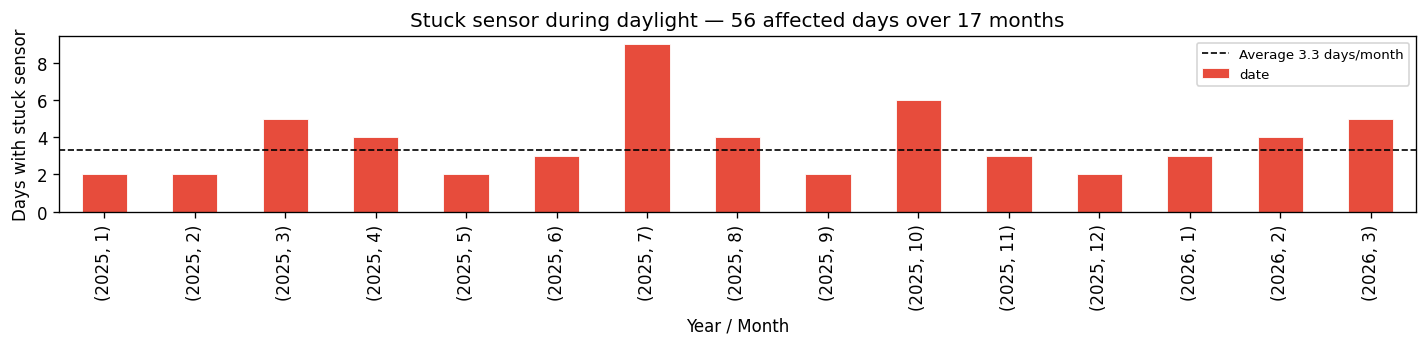

In [160]:
# How many unique days have stuck sensor during daylight?
daylight_neg = large_neg_df[real_daylight].copy()  # slots where sensor stuck AND irradiance > 0

daylight_neg["date"]  = daylight_neg.index.date
daylight_neg["month"] = daylight_neg.index.month
daylight_neg["year"]  = daylight_neg.index.year

days_per_month = daylight_neg.groupby(["year","month"])["date"].nunique()
total_days = daylight_neg["date"].nunique()
total_slots = len(daylight_neg)

print(f"Unique days with stuck sensor during daylight: {total_days}")
print(f"Total 15-min slots affected:                   {total_slots}")
print(f"Average stuck slots per affected day:          {total_slots/total_days:.1f}")
print()
print("Days per month with at least one stuck daylight slot:")
print(days_per_month.to_string())

fig, ax = plt.subplots(figsize=(12, 3))
days_per_month.plot(kind="bar", ax=ax, color="#e74c3c", edgecolor="white", linewidth=0.5)
ax.set_xlabel("Year / Month")
ax.set_ylabel("Days with stuck sensor")
ax.set_title(f"Stuck sensor during daylight — {total_days} affected days over 17 months")
ax.axhline(total_days / 17, color="black", lw=1, linestyle="--",
           label=f"Average {total_days/17:.1f} days/month")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

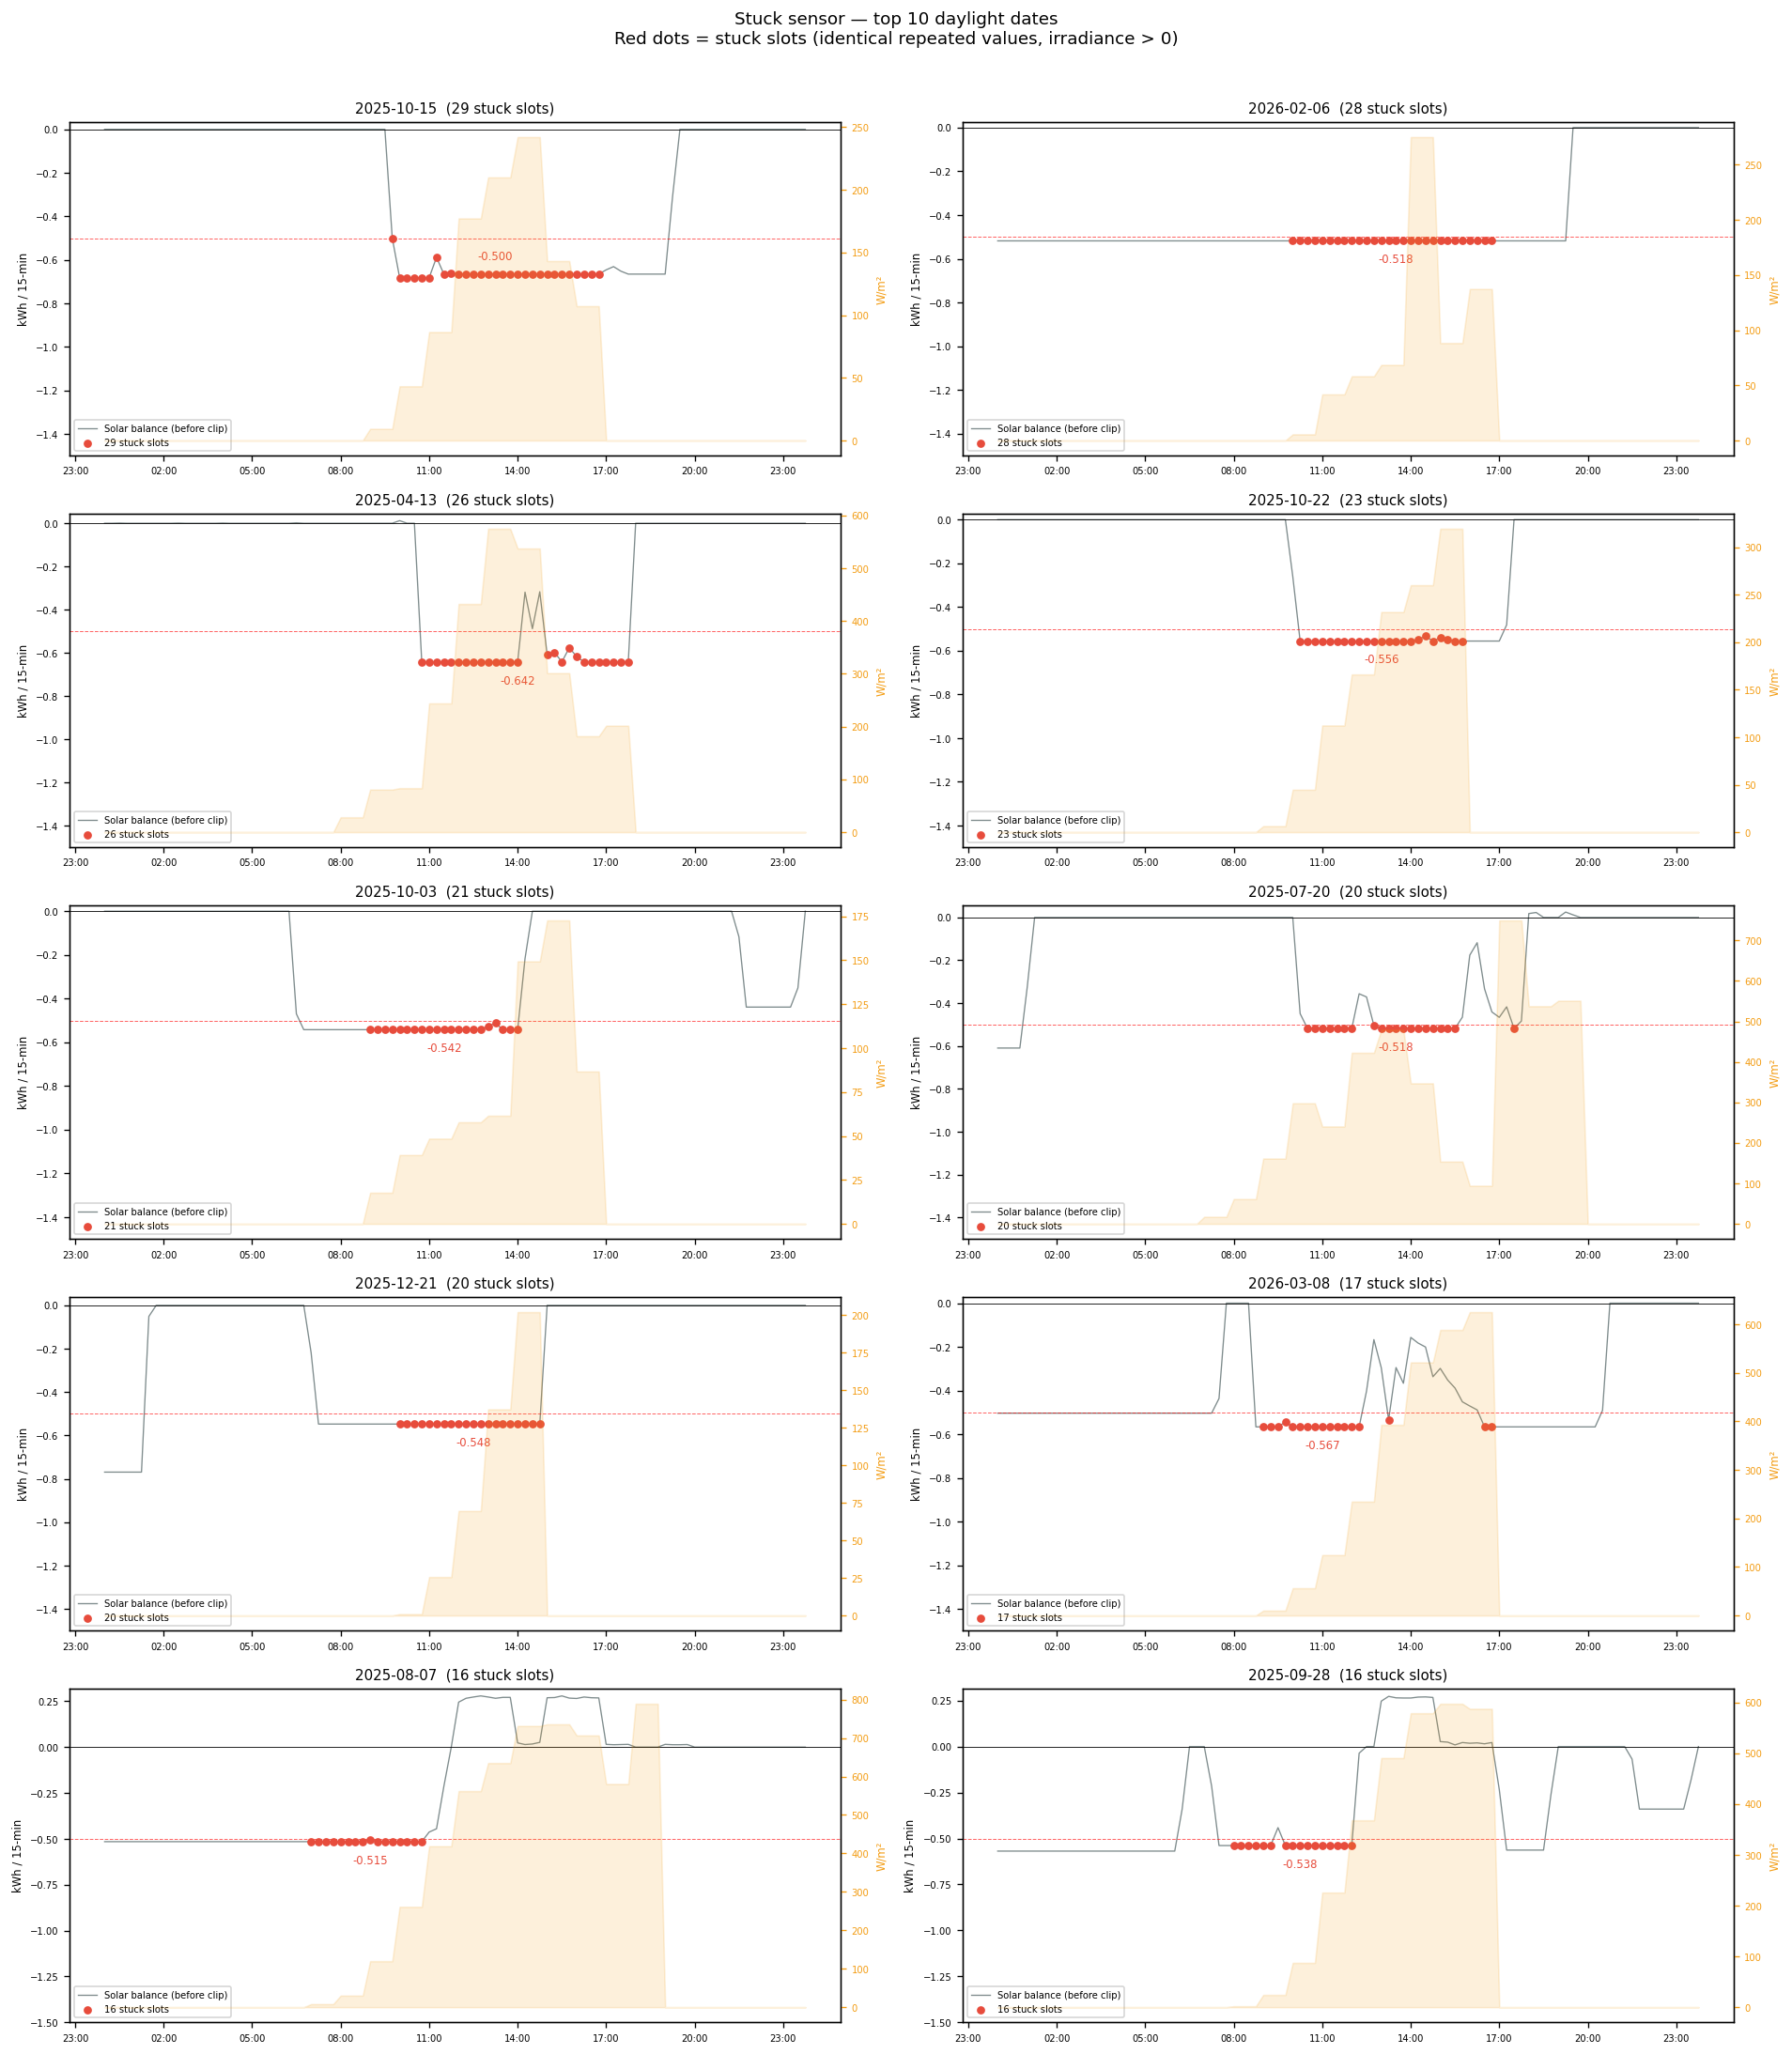

Stuck slots per date (top 10):
date
2025-10-15    29
2026-02-06    28
2025-04-13    26
2025-10-22    23
2025-10-03    21
2025-07-20    20
2025-12-21    20
2026-03-08    17
2025-08-07    16
2025-09-28    16


In [161]:
# Show stuck-sensor incidents during daylight — top 10 dates
daylight_neg = large_neg_df[real_daylight].copy()
daylight_neg["date"] = daylight_neg.index.date

top_dates = daylight_neg.groupby("date").size().sort_values(ascending=False).head(10).index.tolist()

fig, axes = plt.subplots(5, 2, figsize=(16, 18), sharex=False)
axes = axes.flatten()

for i, date in enumerate(top_dates):
    ax = axes[i]
    date_str = str(date)

    day = df.loc[date_str].copy()
    day["solar_neg"] = solar_neg.reindex(day.index)

    stuck = day[(day["solar_neg"] < -0.5) & (day["weer_poa_w_m2"] > 0)]

    ax2 = ax.twinx()
    ax2.fill_between(day.index, day["weer_poa_w_m2"], alpha=0.15, color="#f39c12")
    ax2.set_ylabel("W/m²", fontsize=7, color="#f39c12")
    ax2.tick_params(axis="y", labelsize=6, colors="#f39c12")

    ax.plot(day.index, day["solar_neg"], color="#7f8c8d", lw=0.8, label="Solar balance (before clip)")
    ax.axhline(0, color="black", lw=0.5)
    ax.axhline(-0.5, color="red", lw=0.6, linestyle="--", alpha=0.6)

    if len(stuck) > 0:
        ax.scatter(stuck.index, stuck["solar_neg"], color="#e74c3c", s=18, zorder=5,
                   label=f"{len(stuck)} stuck slots")
        val = stuck["solar_neg"].iloc[0]
        ax.annotate(f"{val:.3f}", xy=(stuck.index[len(stuck)//2], val),
                    xytext=(0, -14), textcoords="offset points",
                    fontsize=7, color="#e74c3c", ha="center")

    ax.set_title(f"{date_str}  ({len(stuck)} stuck slots)", fontsize=9)
    ax.set_ylabel("kWh / 15-min", fontsize=7)
    ax.tick_params(axis="both", labelsize=6)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
    ax.set_ylim(bottom=min(-1.5, day["solar_neg"].min() - 0.1))
    ax.legend(fontsize=6, loc="lower left")

plt.suptitle("Stuck sensor — top 10 daylight dates\n"
             "Red dots = stuck slots (identical repeated values, irradiance > 0)",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

print("Stuck slots per date (top 10):")
print(daylight_neg.groupby("date").size().sort_values(ascending=False).head(10).to_string())


---
## 2a Data quality investigation — SOFAR inverter freeze events

**Symptom:** The energy balance formula produces large negative values (< −0.5 kWh/15-min)
on 56 days during daylight hours (irradiance > 0).

**Root cause:** The SOFAR ME3000SP battery inverter periodically freezes.
When this happens, it physically stops **all** energy flows it controls:
battery charging, battery discharging, and grid injection.
The household switches to full grid import until the inverter recovers.

**Which columns freeze (89 stuck periods analysed):**

| Column | Frozen in % of periods | Source |
|---|---|---|
| `bat_laden_kwh_kw` | 75% | SOFAR |
| `bat_ontladen_kwh_kw` | 70% | SOFAR |
| `injectie_kwh` | 70% | **Fluvius** ← verified |
| `afname_kwh` | 0% | **Fluvius** ← always reliable |

**Key finding — `injectie_kwh` is from Fluvius (not SOFAR):**
`injectie_kwh ≡ fl_injectie_dag + fl_injectie_nacht` (difference = 0 across all 50 104 rows).
During freeze events, `injectie = 0` is the **real Fluvius measurement** — the inverter
physically stopped injecting to the grid, so there was nothing to measure.

**Consequence — the formula is correct:**
During a SOFAR freeze, solar energy is not delivered to the house or grid.
`sl_productie_kwh = 0` after clipping is the right value for optimisation purposes.


**Conclusion for optimisation:**
- No data correction is needed
- `sl_productie_kwh` = delivered solar (formula + clip) is the right input for the LP model
- The 56 freeze days are genuinely days with zero usable solar during the freeze window
- The formula correctly estimates *solar available to the household*


Total stuck periods: 89
Total stuck slots:   547

Column frozen in how many stuck periods (std < 0.001):
  bat_laden_kwh_kw         :   67 / 89  (75%)
  bat_ontladen_kwh_kw      :   62 / 89  (70%)
  afname_kwh               :    0 / 89  (0%)
  verbruik_kwh             :    9 / 89  (10%)
  injectie_kwh             :   62 / 89  (70%)

Worst 10 periods (by n_slots):
      date  n_slots  solar_neg_mean  bat_laden_kwh_kw_std  bat_ontladen_kwh_kw_std  afname_kwh_std  verbruik_kwh_std  injectie_kwh_std
2025-10-15       29        -0.65984                   0.0                      0.0         0.07512           0.08385               0.0
2026-02-06       28        -0.51800                   0.0                      0.0         0.12890           0.12890               0.0
2025-10-22       23        -0.55349                   0.0                      0.0         0.09251           0.08957               0.0
2025-10-03       21        -0.53990                   0.0                      0.0         0.1

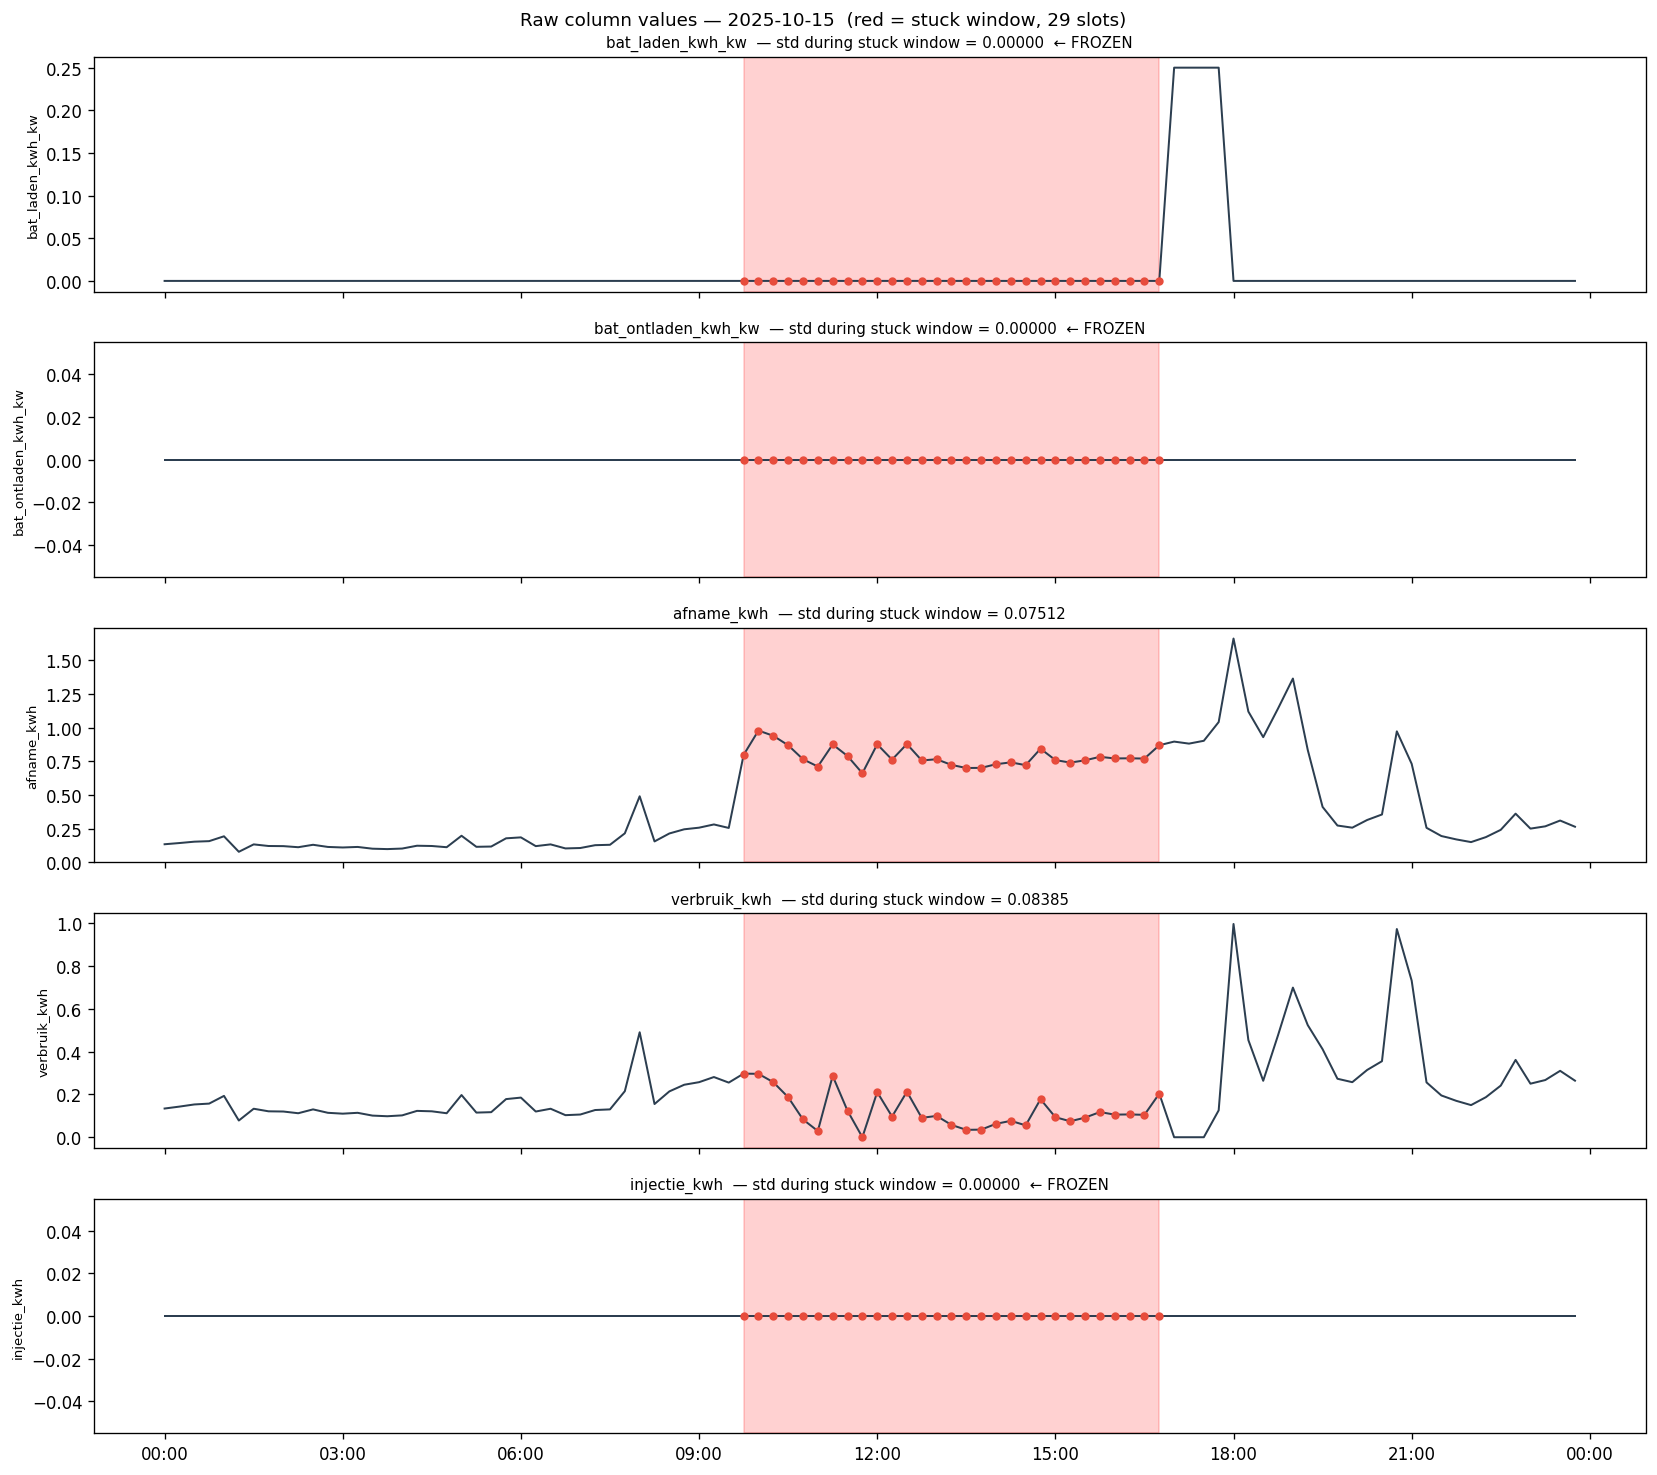

In [162]:
# Which column actually freezes? Analyse each contiguous stuck period separately.
# A column is "stuck" in a period if its std ≈ 0 (all values identical within that window).

stuck_mask = (solar_neg < -0.5) & (df["weer_poa_w_m2"] > 0)

# Group consecutive stuck slots into periods
stuck_group = (stuck_mask != stuck_mask.shift()).cumsum()
stuck_periods = df[stuck_mask].groupby(stuck_group[stuck_mask])

check_cols = ["bat_laden_kwh_kw", "bat_ontladen_kwh_kw",
              "afname_kwh", "verbruik_kwh", "injectie_kwh"]

# For each period: compute std of each column → std ≈ 0 means frozen
period_stats = []
for gid, group in stuck_periods:
    row = {"date": group.index[0].date(), "n_slots": len(group)}
    for col in check_cols:
        row[col + "_std"] = group[col].std()
    row["solar_neg_mean"] = solar_neg.reindex(group.index).mean()
    period_stats.append(row)

stats_df = pd.DataFrame(period_stats)
print(f"Total stuck periods: {len(stats_df)}")
print(f"Total stuck slots:   {stuck_mask.sum()}\n")

# For each column: in how many periods is it frozen (std < 0.001)?
print("Column frozen in how many stuck periods (std < 0.001):")
for col in check_cols:
    n_frozen = (stats_df[col + "_std"] < 0.001).sum()
    pct = n_frozen / len(stats_df) * 100
    print(f"  {col:<25}: {n_frozen:>4} / {len(stats_df)}  ({pct:.0f}%)")

# Show the worst 10 periods
print("\nWorst 10 periods (by n_slots):")
top = stats_df.nlargest(10, "n_slots")[
    ["date", "n_slots", "solar_neg_mean"] + [c + "_std" for c in check_cols]
].round(5)
print(top.to_string(index=False))

# Visual: for the worst single period, plot all candidate columns
worst = stats_df.nlargest(1, "n_slots").iloc[0]
worst_date = str(worst["date"])
day = df.loc[worst_date].copy()
day["solar_neg"] = solar_neg.reindex(day.index)
day["is_stuck"]  = (day["solar_neg"] < -0.5) & (day["weer_poa_w_m2"] > 0)
stuck_rows = day[day["is_stuck"]]

fig, axes = plt.subplots(len(check_cols), 1, figsize=(14, 2.5 * len(check_cols)), sharex=True)
for ax, col in zip(axes, check_cols):
    ax.plot(day.index, day[col], lw=1.2, color="#2c3e50")
    if len(stuck_rows) > 0:
        ax.axvspan(stuck_rows.index[0], stuck_rows.index[-1], alpha=0.18, color="red")
        ax.plot(stuck_rows.index, stuck_rows[col], "o", color="#e74c3c", ms=4, zorder=5)
    col_std = stuck_rows[col].std() if len(stuck_rows) > 1 else 0
    ax.set_ylabel(col, fontsize=8)
    ax.set_title(f"{col}  — std during stuck window = {col_std:.5f}"
                 + ("  ← FROZEN" if col_std < 0.001 else ""), fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.suptitle(f"Raw column values — {worst_date}  (red = stuck window, {int(worst['n_slots'])} slots)",
             fontsize=11)
plt.tight_layout()
plt.show()

In [163]:
# Key question: does injectie_kwh come from Fluvius or SOFAR?
# If injectie_kwh == fl_injectie_dag + fl_injectie_nacht (Fluvius), then
# injectie=0 during stuck events means solar GENUINELY wasn't injected → solar=0 is correct.
# If they differ, injectie_kwh is from SOFAR → it's frozen and we're losing real solar.

df["injectie_fl"] = df["fl_injectie_dag"] + df["fl_injectie_nacht"]
df["injectie_diff"] = (df["injectie_kwh"] - df["injectie_fl"]).abs()

print("Does injectie_kwh == fl_injectie_dag + fl_injectie_nacht ?")
print(f"  Max absolute difference:    {df['injectie_diff'].max():.6f} kWh")
print(f"  Mean absolute difference:   {df['injectie_diff'].mean():.6f} kWh")
print(f"  Rows with diff > 0.001:     {(df['injectie_diff'] > 0.001).sum():,}")
print()

df["afname_fl"] = df["fl_afname_dag"] + df["fl_afname_nacht"]
df["afname_diff"] = (df["afname_kwh"] - df["afname_fl"]).abs()
print("Does afname_kwh == fl_afname_dag + fl_afname_nacht ?")
print(f"  Max absolute difference:    {df['afname_diff'].max():.6f} kWh")
print(f"  Mean absolute difference:   {df['afname_diff'].mean():.6f} kWh")
print(f"  Rows with diff > 0.001:     {(df['afname_diff'] > 0.001).sum():,}")

# Both match → both from Fluvius → clean up helper columns
df.drop(columns=["injectie_fl", "injectie_diff", "afname_fl", "afname_diff"], inplace=True)

print()
print("CONCLUSION:")
print("  injectie_kwh = Fluvius (exact match). During stuck events, injectie=0 is REAL.")
print("  SOFAR physically stopped all flows → solar delivered to house/grid = 0.")
print("  The energy balance formula is CORRECT. No data correction needed.")
print()

Does injectie_kwh == fl_injectie_dag + fl_injectie_nacht ?
  Max absolute difference:    0.000000 kWh
  Mean absolute difference:   0.000000 kWh
  Rows with diff > 0.001:     0

Does afname_kwh == fl_afname_dag + fl_afname_nacht ?
  Max absolute difference:    0.000000 kWh
  Mean absolute difference:   0.000000 kWh
  Rows with diff > 0.001:     0

CONCLUSION:
  injectie_kwh = Fluvius (exact match). During stuck events, injectie=0 is REAL.
  SOFAR physically stopped all flows → solar delivered to house/grid = 0.
  The energy balance formula is CORRECT. No data correction needed.



## 2b. Validation: no solar at night

**Physical constraint:** `sl_productie_kwh` must be **0** whenever solar irradiance is 0
(night, full overcast). The formula derives solar from the energy balance of four
independent meters (OwnDev, Fluvius, SOFAR), so any measurement or timing mismatch
between those meters shows up as a residual that the formula misinterprets as solar.

**Three root causes found:**

| Pattern | Example | Root cause |
|---|---|---|
| `bat_laden = 2.0 kWh` at 01:00 | 2025-02-10 | SOFAR logger spike — inverter internal counter glitch |
| `bat_laden = 0.5`, `afname` too low | many nights | Clock skew between SOFAR and Fluvius: energy lands in adjacent 15-min slot |
| `injectie > 0` at 22:00, `poa = 0` | 2025-06-04 | Fluvius records energy accumulated *up to* 22:00 — real solar from 21:50 gets timestamped as "night" |

**Fix applied in cell 45 (above):**
1. `bat_laden_kwh_kw.clip(lower=0, upper=0.75)` — removes impossible values
2. `solar = 0` wherever `weer_poa_w_m2 == 0` — irradiance is the physical ground truth


Slots with irradiance = 0 : 32,300
  solar > 0  BEFORE fix   : 936  (78.4 kWh total)
  solar > 0  AFTER  fix   : 0  (0.0 kWh total)
Removed fake solar        : 78 kWh


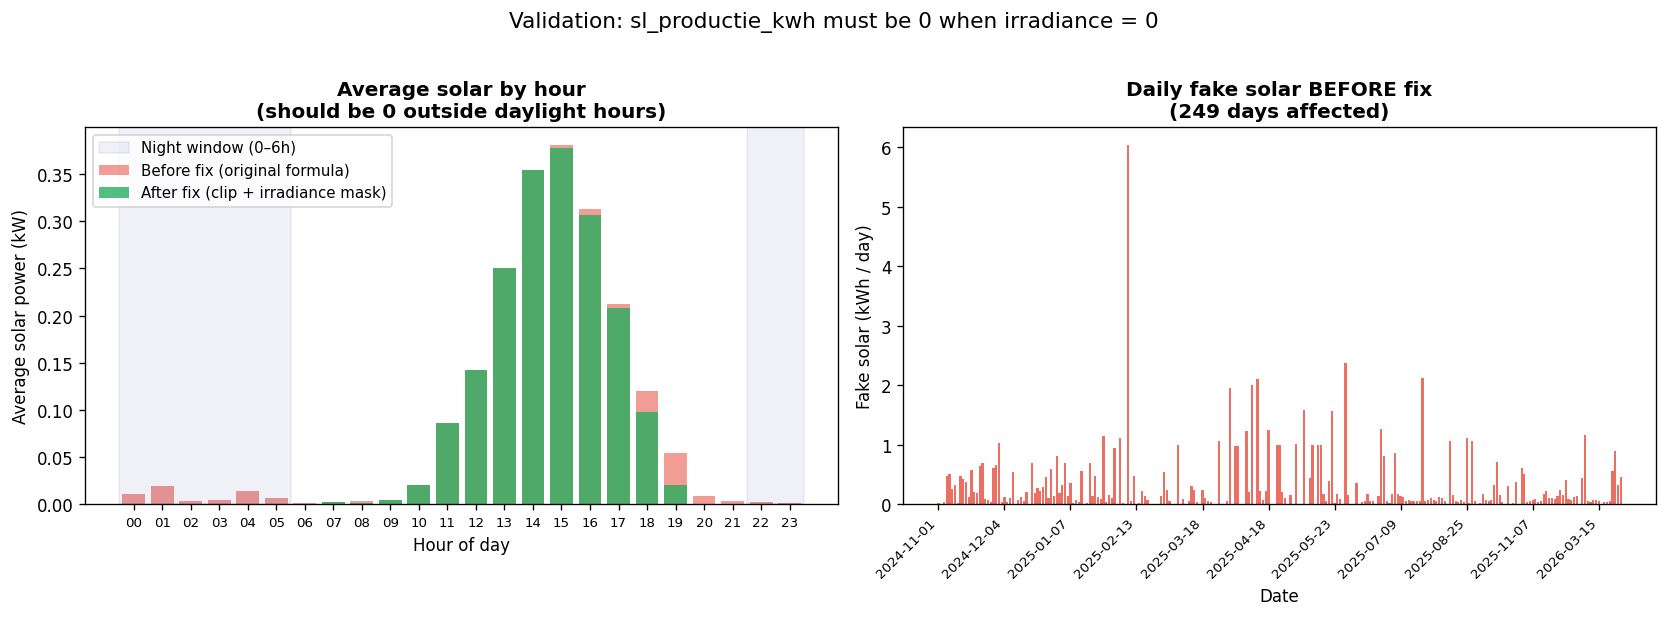

CHECK PASSED: no solar when irradiance = 0


In [164]:
# Validation: solar must be 0 when irradiance is 0

# Version A: original formula (no clip, no irradiance mask)
bat_orig = df["bat_laden_kwh_kw"]
solar_A  = (
    df["verbruik_kwh"] + df["injectie_kwh"]
    + bat_orig - df["bat_ontladen_kwh_kw"]
    - df["afname_kwh"]
).clip(lower=0)
solar_A  = solar_A.where(solar_A > 0.001, 0.0)

# Version B: fixed formula (clip + irradiance mask) — what cell 45 now produces
bat_fixed = df["bat_laden_kwh_kw"].clip(lower=0, upper=0.75)
solar_B   = (
    df["verbruik_kwh"] + df["injectie_kwh"]
    + bat_fixed - df["bat_ontladen_kwh_kw"]
    - df["afname_kwh"]
).clip(lower=0)
solar_B   = solar_B.where(df["weer_poa_w_m2"] > 0, 0.0)
solar_B   = solar_B.where(solar_B > 0.001, 0.0)

# Summary stats
no_irr = df["weer_poa_w_m2"] == 0
fake_A = solar_A[no_irr & (solar_A > 0.001)]
fake_B = solar_B[no_irr & (solar_B > 0.001)]
print(f"Slots with irradiance = 0 : {no_irr.sum():,}")
print(f"  solar > 0  BEFORE fix   : {len(fake_A):,}  ({fake_A.sum():.1f} kWh total)")
print(f"  solar > 0  AFTER  fix   : {len(fake_B):,}  ({fake_B.sum():.1f} kWh total)")
print(f"Removed fake solar        : {solar_A.sum() - solar_B.sum():.0f} kWh")

# Average solar by hour of day
by_hour_A = solar_A.groupby(solar_A.index.hour).mean() * 4
by_hour_B = solar_B.groupby(solar_B.index.hour).mean() * 4
hours     = range(24)

# Daily fake solar totals (before fix)
fake_by_date = (
    solar_A[no_irr]
    .resample("D").sum()
    .loc[lambda s: s > 0.001]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: average solar power by hour
ax = axes[0]
ax.bar(hours, by_hour_A, color="#e74c3c", alpha=0.55, label="Before fix (original formula)")
ax.bar(hours, by_hour_B, color="#27ae60", alpha=0.80, label="After fix (clip + irradiance mask)")
ax.axvspan(-0.5,  5.5, color="navy", alpha=0.06, label="Night window (0–6h)")
ax.axvspan(21.5, 23.5, color="navy", alpha=0.06)
ax.set_xticks(list(hours))
ax.set_xticklabels([f"{h:02d}" for h in hours], fontsize=8)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Average solar power (kW)")
ax.set_title("Average solar by hour\n(should be 0 outside daylight hours)", fontweight="bold")
ax.legend(fontsize=9)

# Right: daily fake solar (before fix)
ax2 = axes[1]
if len(fake_by_date) > 0:
    step = max(1, len(fake_by_date) // 10)
    ax2.bar(range(len(fake_by_date)), fake_by_date.values,
            color="#e74c3c", alpha=0.8, width=0.8)
    ax2.set_xticks(range(0, len(fake_by_date), step))
    ax2.set_xticklabels(
        [str(fake_by_date.index[i].date()) for i in range(0, len(fake_by_date), step)],
        rotation=45, ha="right", fontsize=8)
    ax2.set_xlabel("Date")
    ax2.set_ylabel("Fake solar (kWh / day)")
    ax2.set_title(
        f"Daily fake solar BEFORE fix\n({len(fake_by_date)} days affected)",
        fontweight="bold")
else:
    ax2.text(0.5, 0.5, "No fake solar", ha="center", va="center",
             transform=ax2.transAxes, fontsize=14)
    ax2.set_title("Daily fake solar BEFORE fix", fontweight="bold")

plt.suptitle(
    "Validation: sl_productie_kwh must be 0 when irradiance = 0",
    fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

assert len(fake_B) == 0, f"FAIL: {len(fake_B)} slots still have solar > 0 at irradiance=0"
print("CHECK PASSED: no solar when irradiance = 0")


---
## 2c. Validation: formula ≥ injection (formula < injection days)

Physical constraint: `sl_productie_kwh >= injectie_kwh` must hold every day
(you cannot inject more than you produced). Violations reveal where the formula
underestimates solar. Three known causes:

1. **EV-charging days**: `afname` includes EV load; `verbruik` (OwnDev) does not.
   `ev_energie_kwh` is a per-session lump sum → cannot be added per 15-min slot
   without creating fake solar at session timestamps.

2. **SOC carry-over**: battery net-discharges over the day (starts full, ends low).
   Formula interprets net discharge as "negative solar" → slightly underestimates.

3. **SOFAR freeze artifacts**: inverter froze mid-day; battery columns stuck at a
   constant value (often exact integers like 7.0). Formula uses frozen values → wrong.
   Note: during a freeze, solar was *not delivered* to the household,
   so formula=0 is still the correct LP input (see §SOFAR-freeze above).

Total annual deficit is small (~18 kWh). No correction is applied.

In [165]:
import os, datetime

OPT_FILE = os.path.join("..", "..", "Data", "real_load", "Final", "optimization_input.csv")
DZ_FILE  = os.path.join("..", "..", "Data", "real_load", "Final", "dag_zon_met_verhoudingen.csv")

opt = pd.read_csv(OPT_FILE, index_col="kwartier", parse_dates=True)
daily = opt[["sl_productie_kwh", "injectie_kwh", "ev_energie_kwh",
             "bat_laden_kwh_kw", "bat_ontladen_kwh_kw"]].resample("D").sum()
daily.index = daily.index.date
daily["net_bat"] = daily["bat_laden_kwh_kw"] - daily["bat_ontladen_kwh_kw"]

dz = pd.read_csv(DZ_FILE, parse_dates=["datum"])
dz["datum"] = dz["datum"].dt.date
dz = dz.set_index("datum")

merged = daily.join(dz[["injectie_kwh", "poa_kwh_m2"]], how="inner", rsuffix="_dz")
merged["deficit"] = (merged["injectie_kwh_dz"] - merged["sl_productie_kwh"]).clip(lower=0)
violations = merged[merged["deficit"] > 0].copy()

# Classify cause
violations["cause"] = "freeze/soc"
violations.loc[violations["ev_energie_kwh"] >= 0.5, "cause"] = "EV"
violations.loc[
    (violations["ev_energie_kwh"] < 0.5) & (violations["net_bat"] < -0.5),
    "cause"
] = "SOC carryover"

m2025 = merged[
    [datetime.date(2025,1,1) <= d <= datetime.date(2025,12,31) for d in merged.index]
]
solar_2025   = m2025["sl_productie_kwh"].sum()
deficit_2025 = m2025["deficit"].sum()

print("=== Formula < injection violations ===")
print(f"Total violation days: {len(violations)}")
for cause, grp in violations.groupby("cause"):
    print(f"  {cause:<20s}: {len(grp):>3d} days, {grp['deficit'].sum():>5.1f} kWh deficit")
print()
print("2025 summary:")
print(f"  Solar formula total:   {solar_2025:>6.0f} kWh")
print(f"  Total deficit:         {deficit_2025:>6.1f} kWh")
print(f"  Deficit / formula:     {deficit_2025 / solar_2025 * 100:>5.1f}%")
print()
print("Top 10 worst days:")
top = violations.nlargest(10, "deficit")[
    ["cause", "ev_energie_kwh", "net_bat", "sl_productie_kwh", "injectie_kwh_dz", "deficit"]
]
top.columns = ["cause", "ev_kwh", "net_bat", "solar_formula", "inj_fluvius", "deficit"]
print(top.round(3).to_string())

=== Formula < injection violations ===
Total violation days: 165
  EV                  :  68 days,  11.8 kWh deficit
  SOC carryover       :  16 days,   3.5 kWh deficit
  freeze/soc          :  81 days,  15.1 kWh deficit

2025 summary:
  Solar formula total:      868 kWh
  Total deficit:           22.7 kWh
  Deficit / formula:       2.6%

Top 10 worst days:
                    cause  ev_kwh  net_bat  solar_formula  inj_fluvius  deficit
2025-05-21             EV   4.900      0.0          2.338        3.777    1.439
2025-05-19             EV   7.020      0.0          1.826        2.986    1.160
2025-06-29     freeze/soc   0.000      0.0         14.746       15.720    0.974
2025-09-13             EV   2.918     -2.0          0.166        0.947    0.781
2025-01-09             EV  11.223      0.0          0.000        0.733    0.733
2025-10-25  SOC carryover   0.000     -1.0          0.000        0.714    0.714
2025-12-19     freeze/soc   0.000      2.0          0.066        0.754    0.688


In [166]:
# Resample 15-min -> hourly
kwh_cols = ["afname_kwh", "injectie_kwh", "verbruik_kwh", "sl_productie_kwh",
            "bat_laden_kwh_kw", "bat_ontladen_kwh_kw",
            "fl_afname_dag", "fl_afname_nacht", "fl_injectie_dag", "fl_injectie_nacht"]
kw_cols  = ["afname_kw", "terugave_kw", "bat_laden_kw", "bat_ontladen_kw", "weer_poa_w_m2"]
soc_cols = ["soc_begin", "soc_eind"]

hourly = df[kwh_cols].resample("h").sum(min_count=1)
hourly[kw_cols]  = df[kw_cols].resample("h").mean()
hourly[soc_cols] = df[soc_cols].resample("h").mean()
hourly["tarief"] = df["tarief"].resample("h").first()
hourly["hour"]   = hourly.index.hour
hourly["month"]  = pd.DatetimeIndex(hourly.index).month
hourly["date"]   = pd.DatetimeIndex(hourly.index).date

n = len(hourly)
for col in ["afname_kwh", "sl_productie_kwh", "bat_laden_kwh_kw", "soc_begin"]:
    pct = hourly[col].notna().sum() / n * 100
    print(f"{col:22s}: {pct:.0f}% coverage")

hourly[["afname_kwh","injectie_kwh","sl_productie_kwh",
        "bat_laden_kwh_kw","bat_ontladen_kwh_kw","verbruik_kwh"]].describe().round(3)


afname_kwh            : 100% coverage
sl_productie_kwh      : 100% coverage
bat_laden_kwh_kw      : 100% coverage
soc_begin             : 3% coverage


,afname_kwh,injectie_kwh,sl_productie_kwh,bat_laden_kwh_kw,bat_ontladen_kwh_kw,verbruik_kwh
count,12526.000,12526.000,12526.000,12526.000,12526.000,12526.000
mean,0.922,0.021,0.078,0.161,0.149,0.712
std,1.010,0.084,0.296,0.448,0.412,0.574
min,0.000,0.000,0.000,-1.000,0.000,0.000
25%,0.168,0.000,0.000,0.000,0.000,0.336
50%,0.602,0.000,0.000,0.000,0.000,0.622
75%,1.233,0.013,0.000,0.000,0.000,1.000
max,6.869,2.105,2.105,8.000,4.000,5.797


## 3. Energy flows — full period overview

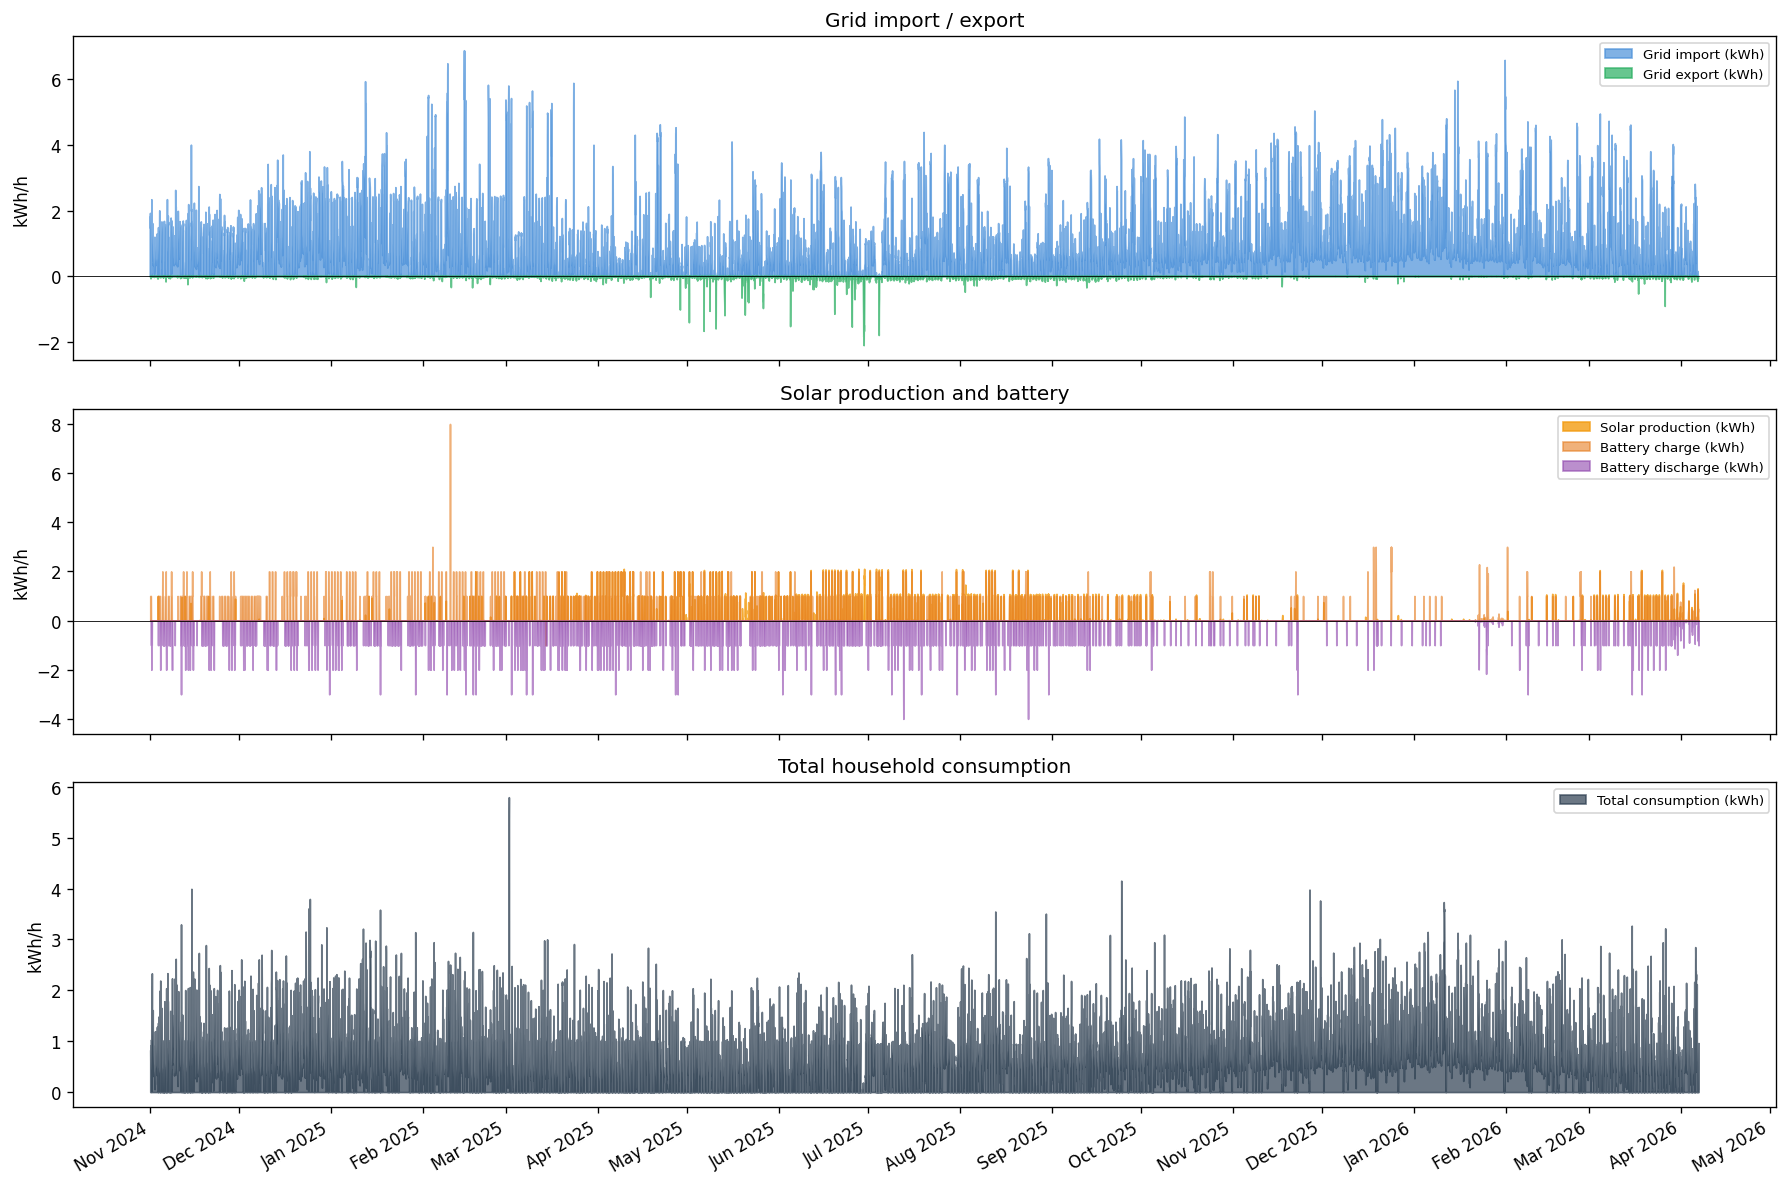

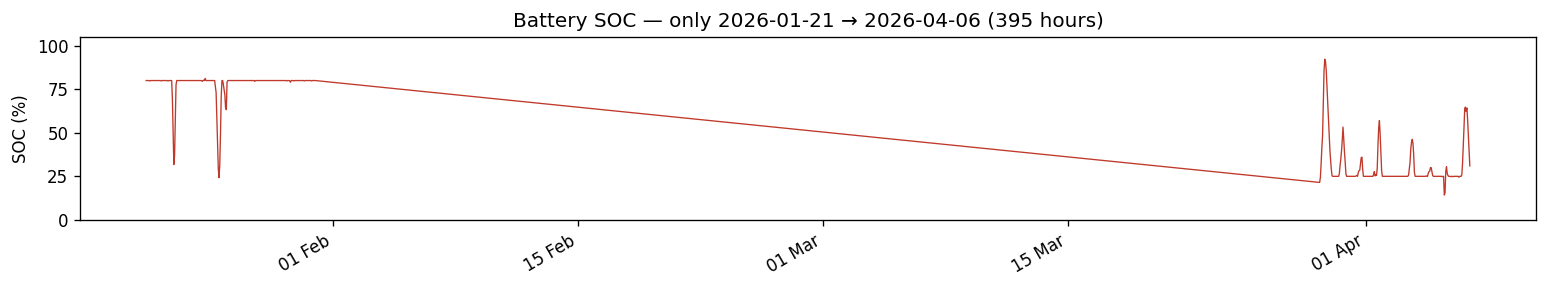

In [167]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

ax = axes[0]
ax.fill_between(hourly.index, hourly["afname_kwh"],    alpha=0.7, color="#4a90d9", label="Grid import (kWh)")
ax.fill_between(hourly.index, -hourly["injectie_kwh"], alpha=0.7, color="#27ae60", label="Grid export (kWh)")
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("kWh/h")
ax.set_title("Grid import / export")
ax.legend(loc="upper right", fontsize=8)

ax = axes[1]
ax.fill_between(hourly.index, hourly["sl_productie_kwh"].fillna(0), alpha=0.8, color="#f39c12", label="Solar production (kWh)")
ax.fill_between(hourly.index,  hourly["bat_laden_kwh_kw"].fillna(0),   alpha=0.6, color="#e67e22", label="Battery charge (kWh)")
ax.fill_between(hourly.index, -hourly["bat_ontladen_kwh_kw"].fillna(0),alpha=0.6, color="#8e44ad", label="Battery discharge (kWh)")
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("kWh/h")
ax.set_title("Solar production and battery")
ax.legend(loc="upper right", fontsize=8)

ax = axes[2]
ax.fill_between(hourly.index, hourly["verbruik_kwh"].fillna(0), alpha=0.7, color="#2c3e50", label="Total consumption (kWh)")
ax.set_ylabel("kWh/h")
ax.set_title("Total household consumption")
ax.legend(loc="upper right", fontsize=8)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate(rotation=30, ha="right")
plt.tight_layout()
plt.show()

soc_data = hourly["soc_begin"].dropna()
if len(soc_data) > 0:
    fig2, ax2 = plt.subplots(figsize=(13, 2.5))
    ax2.plot(soc_data.index, soc_data, color="#c0392b", lw=0.8)
    ax2.set_ylabel("SOC (%)")
    ax2.set_ylim(0, 105)
    ax2.set_title(f"Battery SOC — only {soc_data.index.min().date()} → {soc_data.index.max().date()} ({len(soc_data)} hours)")
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    fig2.autofmt_xdate(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


## 3b. Monthly energy totals (kWh/month)

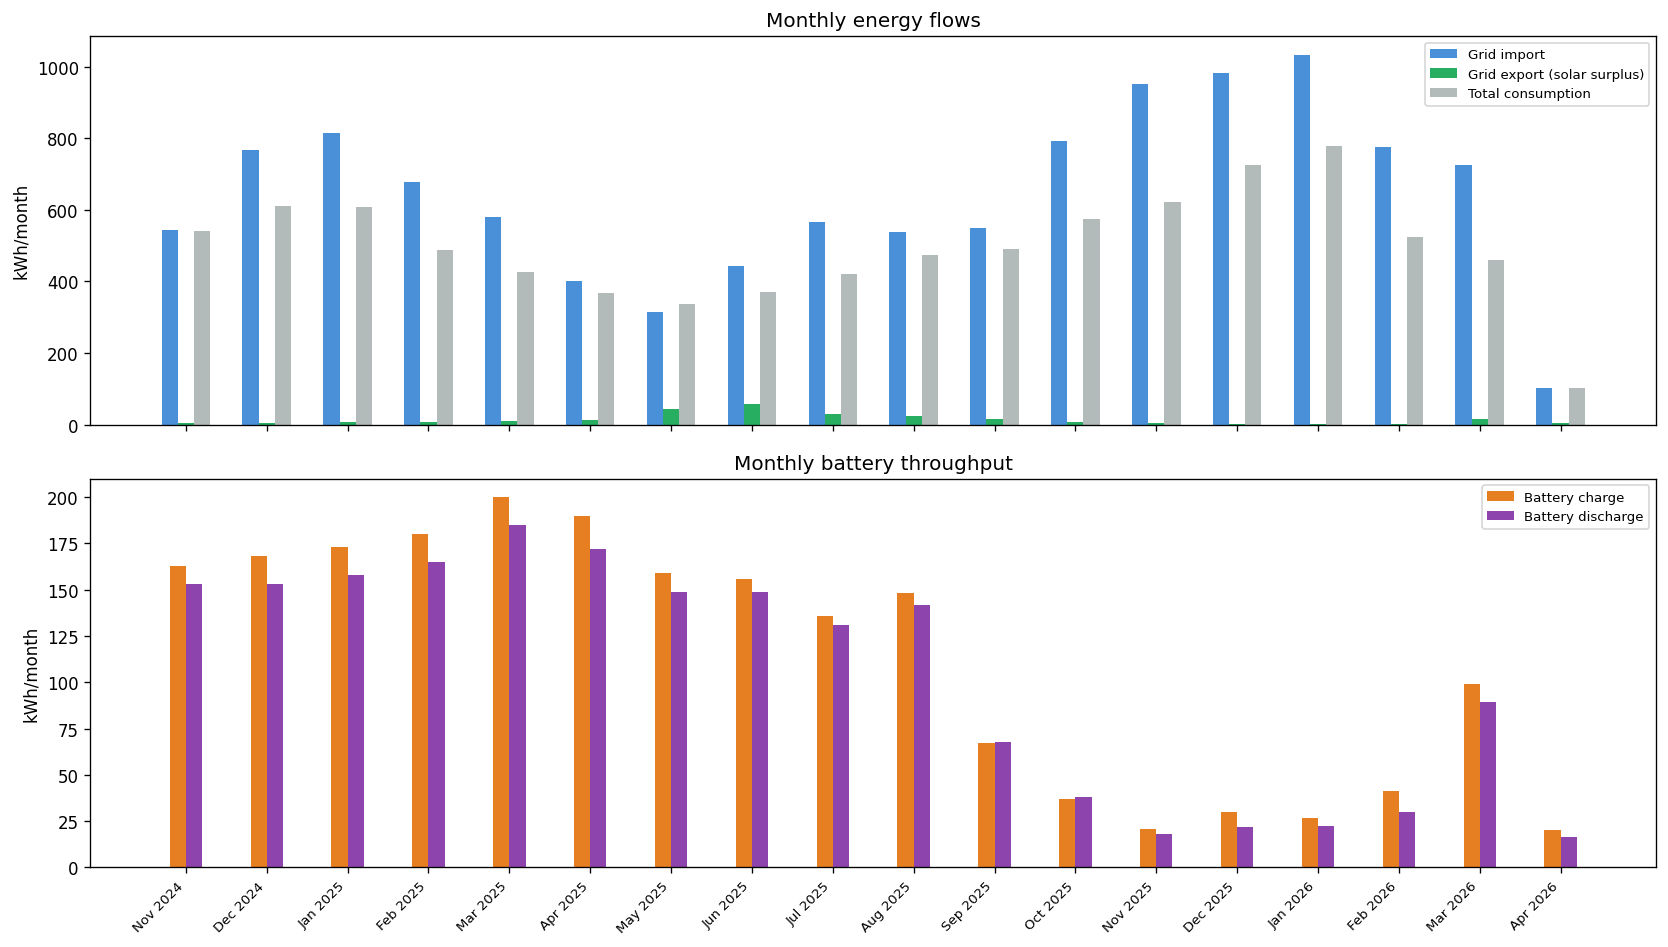

          afname_kwh  injectie_kwh  bat_laden_kwh_kw  verbruik_kwh
kwartier                                                          
Nov 2024       543.6           5.5             163.0         540.7
Dec 2024       766.2           5.6             168.0         609.6
Jan 2025       815.0           6.3             173.0         607.3
Feb 2025       678.9           8.0             180.0         487.6
Mar 2025       579.2          10.6             200.0         427.2
Apr 2025       401.6          13.5             190.0         367.7
May 2025       315.9          42.6             159.0         337.3
Jun 2025       442.7          57.9             156.0         371.1
Jul 2025       565.5          31.0             136.0         419.4
Aug 2025       537.0          25.4             148.0         472.7
Sep 2025       548.2          16.8              67.0         489.8
Oct 2025       792.3           6.2              37.0         575.6
Nov 2025       950.8           3.7              21.0         6

In [168]:
monthly = hourly[["afname_kwh","injectie_kwh","bat_laden_kwh_kw","bat_ontladen_kwh_kw","verbruik_kwh"]].resample("ME").sum(min_count=1)
monthly.index = monthly.index.strftime("%b %Y")

x = range(len(monthly))
w = 0.2

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.bar([i - w for i in x], monthly["afname_kwh"],   w, color="#4a90d9", label="Grid import")
ax1.bar([i     for i in x], monthly["injectie_kwh"], w, color="#27ae60", label="Grid export (solar surplus)")
ax1.bar([i + w for i in x], monthly["verbruik_kwh"], w, color="#7f8c8d", label="Total consumption", alpha=0.6)
ax1.set_ylabel("kWh/month")
ax1.set_title("Monthly energy flows")
ax1.legend(fontsize=8)

ax2.bar([i - w/2 for i in x], monthly["bat_laden_kwh_kw"],   w, color="#e67e22", label="Battery charge")
ax2.bar([i + w/2 for i in x], monthly["bat_ontladen_kwh_kw"],w, color="#8e44ad", label="Battery discharge")
ax2.set_ylabel("kWh/month")
ax2.set_title("Monthly battery throughput")
ax2.legend(fontsize=8)
ax2.set_xticks(list(x))
ax2.set_xticklabels(list(monthly.index), rotation=45, ha="right", fontsize=8)

plt.tight_layout()
plt.show()

print(monthly[["afname_kwh","injectie_kwh","bat_laden_kwh_kw","verbruik_kwh"]].round(1).to_string())


## 4. Average day profile (by hour of day)

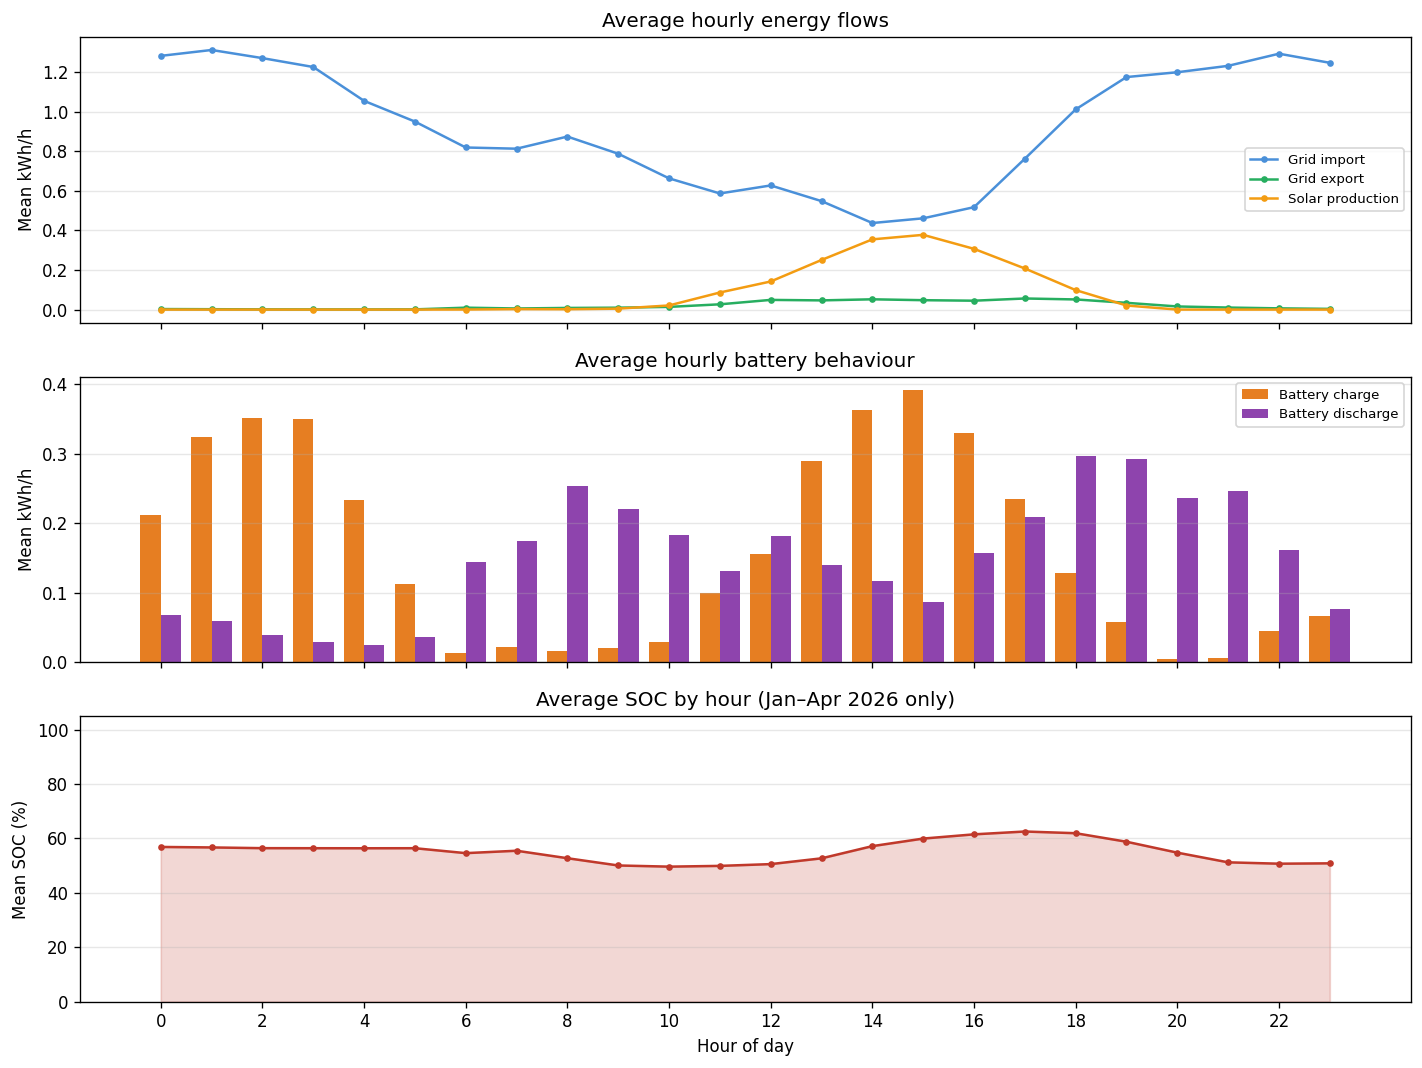

In [169]:
by_hour = hourly.groupby("hour")[["afname_kwh","injectie_kwh","sl_productie_kwh",
                                   "bat_laden_kwh_kw","bat_ontladen_kwh_kw","soc_begin"]].mean()

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

ax = axes[0]
ax.plot(by_hour.index, by_hour["afname_kwh"],       color="#4a90d9", marker="o", ms=3, label="Grid import")
ax.plot(by_hour.index, by_hour["injectie_kwh"],     color="#27ae60", marker="o", ms=3, label="Grid export")
ax.plot(by_hour.index, by_hour["sl_productie_kwh"], color="#f39c12", marker="o", ms=3, label="Solar production")
ax.set_ylabel("Mean kWh/h")
ax.set_title("Average hourly energy flows")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

ax = axes[1]
ax.bar(by_hour.index - 0.2, by_hour["bat_laden_kwh_kw"],   0.4, color="#e67e22", label="Battery charge")
ax.bar(by_hour.index + 0.2, by_hour["bat_ontladen_kwh_kw"],0.4, color="#8e44ad", label="Battery discharge")
ax.set_ylabel("Mean kWh/h")
ax.set_title("Average hourly battery behaviour")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

ax = axes[2]
soc_by_hour = by_hour["soc_begin"].dropna()
if len(soc_by_hour) > 0:
    ax.plot(soc_by_hour.index, soc_by_hour.values, color="#c0392b", marker="o", ms=3)
    ax.fill_between(soc_by_hour.index, soc_by_hour.values, alpha=0.2, color="#c0392b")
    ax.set_title("Average SOC by hour (Jan–Apr 2026 only)")
else:
    ax.text(12, 50, "No SOC data", ha="center", fontsize=12, color="gray")
ax.set_ylabel("Mean SOC (%)")
ax.set_ylim(0, 105)
ax.set_xlabel("Hour of day")
ax.set_xticks(range(0, 24, 2))
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Solar production analysis

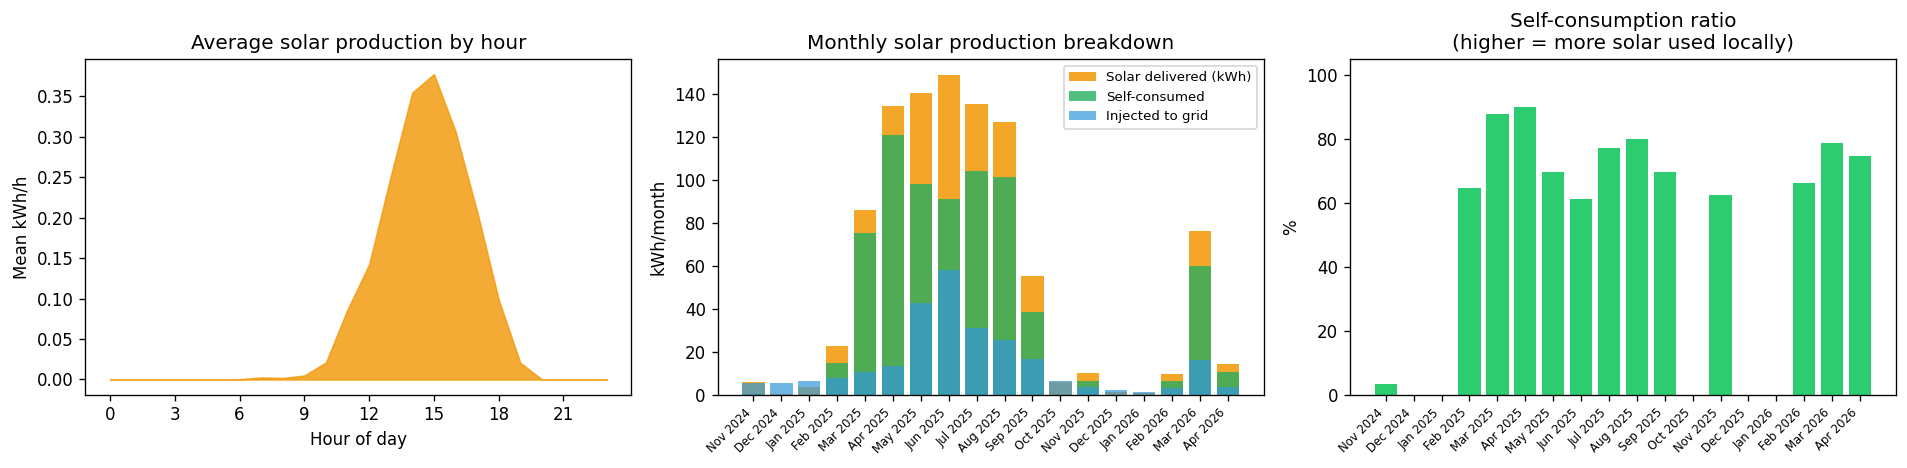

Total solar delivered (formula): 978 kWh
Injected to grid:              260 kWh  (27%)
Self-consumed locally:         718 kWh  (73%)


In [170]:
solar_by_hour = hourly.groupby("hour")["sl_productie_kwh"].mean()

solar_monthly = hourly[["sl_productie_kwh","injectie_kwh"]].resample("ME").sum(min_count=1)
solar_monthly["self_consumption_kwh"] = (solar_monthly["sl_productie_kwh"] - solar_monthly["injectie_kwh"]).clip(lower=0)
solar_monthly.index = solar_monthly.index.strftime("%b %Y")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Average solar production by hour of day
ax = axes[0]
ax.fill_between(solar_by_hour.index, solar_by_hour.values, color="#f39c12", alpha=0.85)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean kWh/h")
ax.set_title("Average solar production by hour")
ax.set_xticks(range(0, 24, 3))

# Monthly: production vs injection vs self-consumption
ax = axes[1]
x = range(len(solar_monthly))
ax.bar(x, solar_monthly["sl_productie_kwh"],       color="#f39c12", alpha=0.9, label="Solar delivered (kWh)")
ax.bar(x, solar_monthly["self_consumption_kwh"],    color="#27ae60", alpha=0.8, label="Self-consumed")
ax.bar(x, solar_monthly["injectie_kwh"],            color="#3498db", alpha=0.7, label="Injected to grid")
ax.set_xticks(list(x))
ax.set_xticklabels(list(solar_monthly.index), rotation=45, ha="right", fontsize=7)
ax.set_ylabel("kWh/month")
ax.set_title("Monthly solar production breakdown")
ax.legend(fontsize=8)

# Self-consumption ratio
ratio = (solar_monthly["self_consumption_kwh"] / solar_monthly["sl_productie_kwh"] * 100).fillna(0)
ax = axes[2]
ax.bar(x, ratio, color="#2ecc71")
ax.set_xticks(list(x))
ax.set_xticklabels(list(solar_monthly.index), rotation=45, ha="right", fontsize=7)
ax.set_ylabel("%")
ax.set_title("Self-consumption ratio\n(higher = more solar used locally)")
ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

total_yield  = hourly["sl_productie_kwh"].sum()
total_inject = hourly["injectie_kwh"].sum()
total_self   = (total_yield - total_inject).clip(0) if total_inject < total_yield else 0
print(f"Total solar delivered (formula): {total_yield:.0f} kWh")
print(f"Injected to grid:              {total_inject:.0f} kWh  ({total_inject/total_yield*100:.0f}%)")
print(f"Self-consumed locally:         {total_self:.0f} kWh  ({total_self/total_yield*100:.0f}%)")


## 6. Battery analysis — SOC and cycling

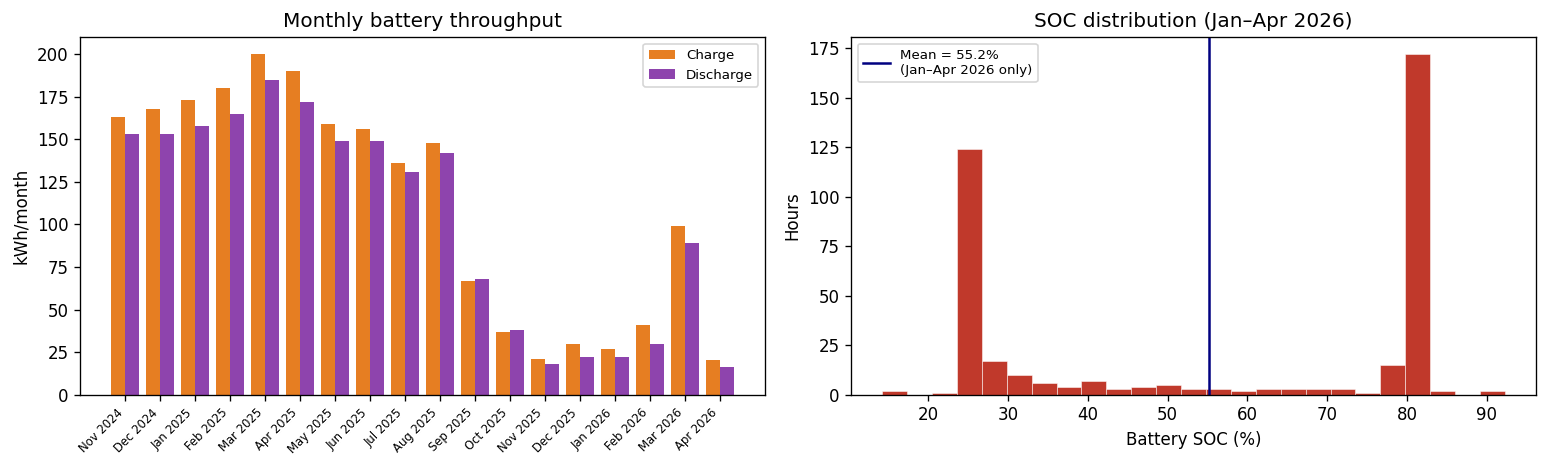

Total charge throughput (521 days): 2014 kWh
Full equivalent cycles:  403  (0.77 EFC/day ≈ 282 EFC/year)
Warranty: 6000 EFC → estimated lifespan: 21.3 years at this rate


In [171]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Monthly battery throughput
bat_monthly = hourly[["bat_laden_kwh_kw","bat_ontladen_kwh_kw"]].resample("ME").sum(min_count=1)
ax = axes[0]
x = range(len(bat_monthly))
ax.bar([i - 0.2 for i in x], bat_monthly["bat_laden_kwh_kw"],   0.4, color="#e67e22", label="Charge")
ax.bar([i + 0.2 for i in x], bat_monthly["bat_ontladen_kwh_kw"],0.4, color="#8e44ad", label="Discharge")
ax.set_xticks(list(x))
ax.set_xticklabels(bat_monthly.index.strftime("%b %Y"), rotation=45, ha="right", fontsize=7)
ax.set_ylabel("kWh/month")
ax.set_title("Monthly battery throughput")
ax.legend(fontsize=8)

BATTERY_KWH = 5.0  # usable capacity (BYD LFP)
total_charge = hourly["bat_laden_kwh_kw"].sum()
n_days = (hourly.index.max() - hourly.index.min()).days
efc = total_charge / BATTERY_KWH

ax = axes[1]
soc_valid = hourly["soc_begin"].dropna()
ax.hist(soc_valid, bins=25, color="#c0392b", edgecolor="white", linewidth=0.3)
ax.axvline(soc_valid.mean(), color="navy", lw=1.5,
           label=f"Mean = {soc_valid.mean():.1f}%\n(Jan–Apr 2026 only)")
ax.set_xlabel("Battery SOC (%)")
ax.set_ylabel("Hours")
ax.set_title("SOC distribution (Jan–Apr 2026)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Total charge throughput ({n_days} days): {total_charge:.0f} kWh")
print(f"Full equivalent cycles:  {efc:.0f}  ({efc/n_days:.2f} EFC/day ≈ {efc/n_days*365:.0f} EFC/year)")
print(f"Warranty: 6000 EFC → estimated lifespan: {6000 / (efc/n_days*365):.1f} years at this rate")


## 7. Tariff split — dag vs nacht

Energy totals by tariff (kWh):
        afname_kwh  injectie_kwh  bat_laden_kwh_kw  bat_ontladen_kwh_kw
tarief                                                                 
dag         3436.0         177.0             747.0               1077.0
nacht       8119.0          82.0            1267.0                784.0

Grid import breakdown:
  dag       : 3436 kWh  (29.7%)
  nacht     : 8119 kWh  (70.3%)

Battery charge breakdown:
  dag       : 747 kWh  (37.1%)
  nacht     : 1267 kWh  (62.9%)


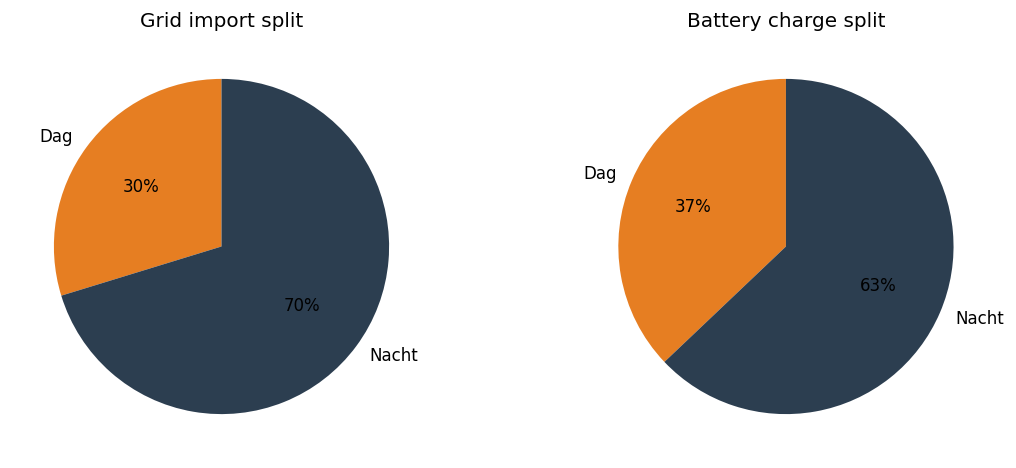

In [172]:
tarief = hourly.groupby("tarief")[["afname_kwh","injectie_kwh","bat_laden_kwh_kw","bat_ontladen_kwh_kw"]].sum()
print("Energy totals by tariff (kWh):")
print(tarief.round(0))

total_import = tarief["afname_kwh"].sum()
print(f"\nGrid import breakdown:")
for t in tarief.index:
    print(f"  {t:10s}: {tarief.loc[t,'afname_kwh']:.0f} kWh  ({tarief.loc[t,'afname_kwh']/total_import*100:.1f}%)")

total_charge = tarief["bat_laden_kwh_kw"].sum()
print(f"\nBattery charge breakdown:")
for t in tarief.index:
    print(f"  {t:10s}: {tarief.loc[t,'bat_laden_kwh_kw']:.0f} kWh  ({tarief.loc[t,'bat_laden_kwh_kw']/total_charge*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, title in zip(axes,
                           ["afname_kwh",      "bat_laden_kwh_kw"],
                           ["Grid import split","Battery charge split"]):
    vals = [tarief.loc[t, col] if t in tarief.index else 0 for t in ["dag","nacht"]]
    ax.pie(vals, labels=["Dag", "Nacht"], colors=["#e67e22","#2c3e50"],
           autopct="%1.0f%%", startangle=90, textprops={"fontsize": 10})
    ax.set_title(title)

plt.tight_layout()
plt.show()


---
## 7b. Battery behavior vs day/night tariff

The real SOFAR ME3000SP uses a simple rule: charge at *nacht* tariff (22:00–06:00 + weekends),
discharge at *dag* tariff. The chart below shows the average charge/discharge per hour.

Two charging peaks are expected and both correct:
- **00–05 h** — grid charging during cheap nacht tariff
- **11–17 h** — solar surplus charging the battery (free energy, not a tariff violation)

The SOFAR does **not** react to EPEX spot prices within a tariff period —
that is the gap the LP optimisation (S2/S3) aims to close.

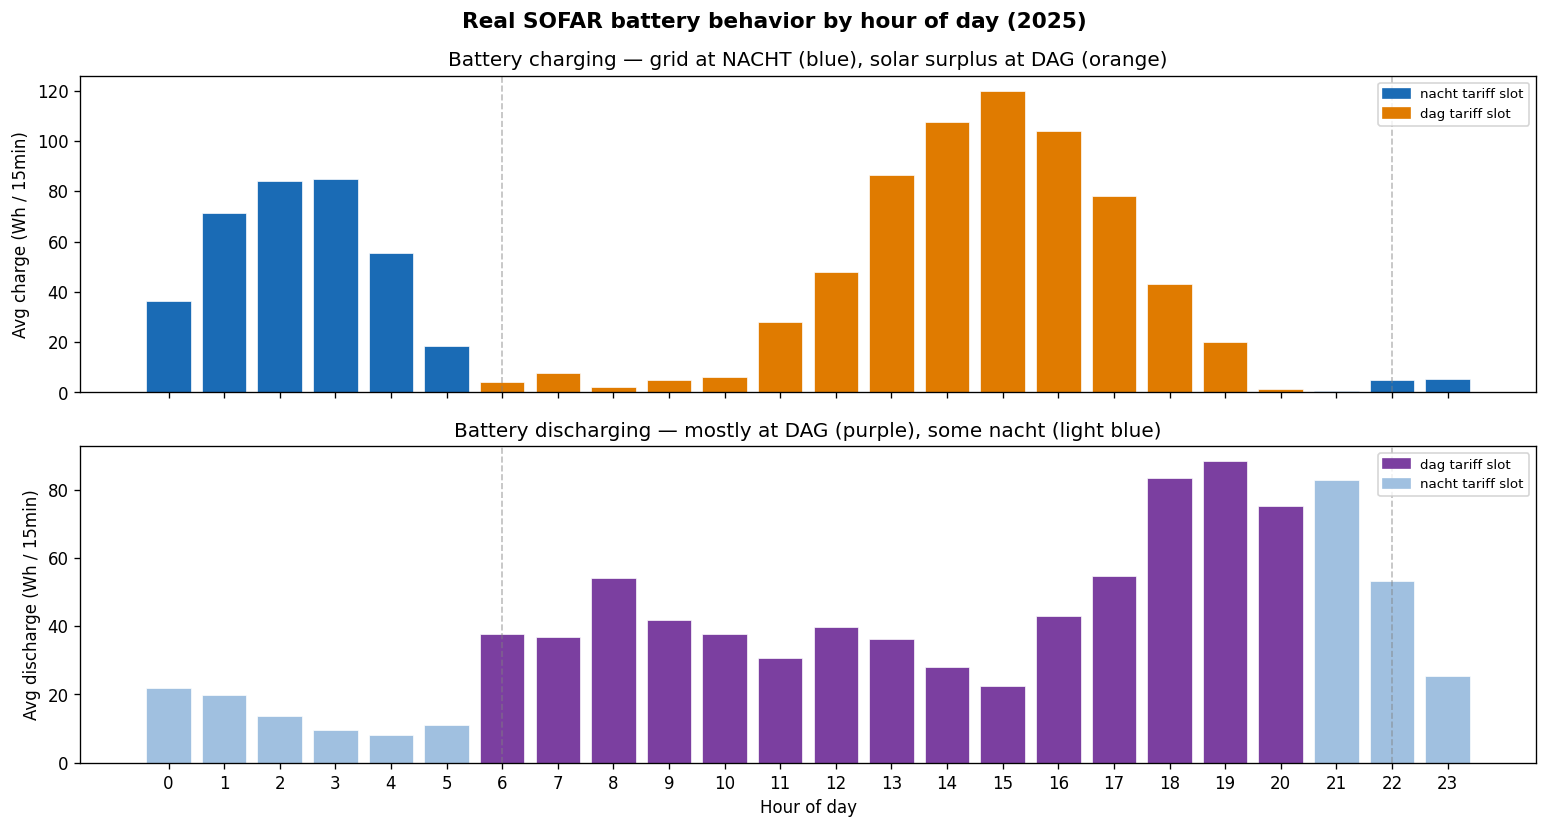

Slots where battery charges:   4,764
  of which at nacht tariff:    51.2%
  of which at dag tariff:      48.8%  (← mostly solar surplus)
Slots where battery discharges:4,872
  of which at dag tariff:      53.3%
  of which at nacht tariff:    46.7%


In [173]:
import os
OPT_FILE = os.path.join("..", "..", "Data", "real_load", "Final", "optimization_input.csv")
opt = pd.read_csv(OPT_FILE, index_col="kwartier", parse_dates=True)

import matplotlib.patches as mpatches

opt2025 = opt[(opt.index >= "2025-01-01") & (opt.index < "2026-01-01")].copy()
opt2025["hour"] = opt2025.index.hour

by_hour = opt2025.groupby("hour")[["bat_laden_kwh_kw", "bat_ontladen_kwh_kw", "tarief"]].agg(
    laden=("bat_laden_kwh_kw", "mean"),
    ontladen=("bat_ontladen_kwh_kw", "mean"),
    tarief=("tarief", lambda x: x.value_counts().idxmax()),  # majority tarief for that hour
)

colors_l = ["#1a6bb5" if t == "nacht" else "#e07b00" for t in by_hour["tarief"]]
colors_d = ["#7b3fa0" if t == "dag"   else "#a0c0e0" for t in by_hour["tarief"]]

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
fig.suptitle("Real SOFAR battery behavior by hour of day (2025)", fontsize=13, fontweight="bold")

ax1 = axes[0]
ax1.bar(by_hour.index, by_hour["laden"] * 1000, color=colors_l, edgecolor="white", linewidth=0.4)
ax1.set_ylabel("Avg charge (Wh / 15min)")
ax1.set_title("Battery charging — grid at NACHT (blue), solar surplus at DAG (orange)")
ax1.axvline(6,  color="gray", lw=1, ls="--", alpha=0.5)
ax1.axvline(22, color="gray", lw=1, ls="--", alpha=0.5)
ax1.legend(handles=[
    mpatches.Patch(color="#1a6bb5", label="nacht tariff slot"),
    mpatches.Patch(color="#e07b00", label="dag tariff slot"),
], loc="upper right", fontsize=8)

ax2 = axes[1]
ax2.bar(by_hour.index, by_hour["ontladen"] * 1000, color=colors_d, edgecolor="white", linewidth=0.4)
ax2.set_ylabel("Avg discharge (Wh / 15min)")
ax2.set_title("Battery discharging — mostly at DAG (purple), some nacht (light blue)")
ax2.set_xlabel("Hour of day")
ax2.axvline(6,  color="gray", lw=1, ls="--", alpha=0.5)
ax2.axvline(22, color="gray", lw=1, ls="--", alpha=0.5)
ax2.set_xticks(range(24))
ax2.legend(handles=[
    mpatches.Patch(color="#7b3fa0", label="dag tariff slot"),
    mpatches.Patch(color="#a0c0e0", label="nacht tariff slot"),
], loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

# Summary stats
charged    = opt2025[opt2025["bat_laden_kwh_kw"]    > 0.001]
discharged = opt2025[opt2025["bat_ontladen_kwh_kw"] > 0.001]
print(f"Slots where battery charges:   {len(charged):,}")
print(f"  of which at nacht tariff:    {(charged['tarief']=='nacht').mean()*100:.1f}%")
print(f"  of which at dag tariff:      {(charged['tarief']=='dag').mean()*100:.1f}%  (← mostly solar surplus)")
print(f"Slots where battery discharges:{len(discharged):,}")
print(f"  of which at dag tariff:      {(discharged['tarief']=='dag').mean()*100:.1f}%")
print(f"  of which at nacht tariff:    {(discharged['tarief']=='nacht').mean()*100:.1f}%")

## 8. Zoom — single day (15-min resolution)

Change `DAY` to any date in the dataset.


In [174]:
%pip install ipywidgets --no-deps -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [175]:
# Which dates actually have SOC data?
soc_days = df["soc_begin"].dropna().index.normalize().unique()
print(f"Total dates with SOC data: {len(soc_days)}")
print(soc_days[:20])

# Check specific demo dates
for d in ["2026-01-15", "2026-03-15"]:
    day = df.loc[d]
    n = day["soc_begin"].notna().sum()
    print(f"{d}: {n} non-null SOC rows out of {len(day)}")

Total dates with SOC data: 18
DatetimeIndex(['2026-01-21', '2026-01-22', '2026-01-23', '2026-01-24',
               '2026-01-25', '2026-01-26', '2026-01-27', '2026-01-29',
               '2026-01-30', '2026-03-29', '2026-03-30', '2026-03-31',
               '2026-04-01', '2026-04-02', '2026-04-03', '2026-04-04',
               '2026-04-05', '2026-04-06'],
              dtype='datetime64[us]', name='kwartier', freq=None)
2026-01-15: 0 non-null SOC rows out of 96
2026-03-15: 0 non-null SOC rows out of 96


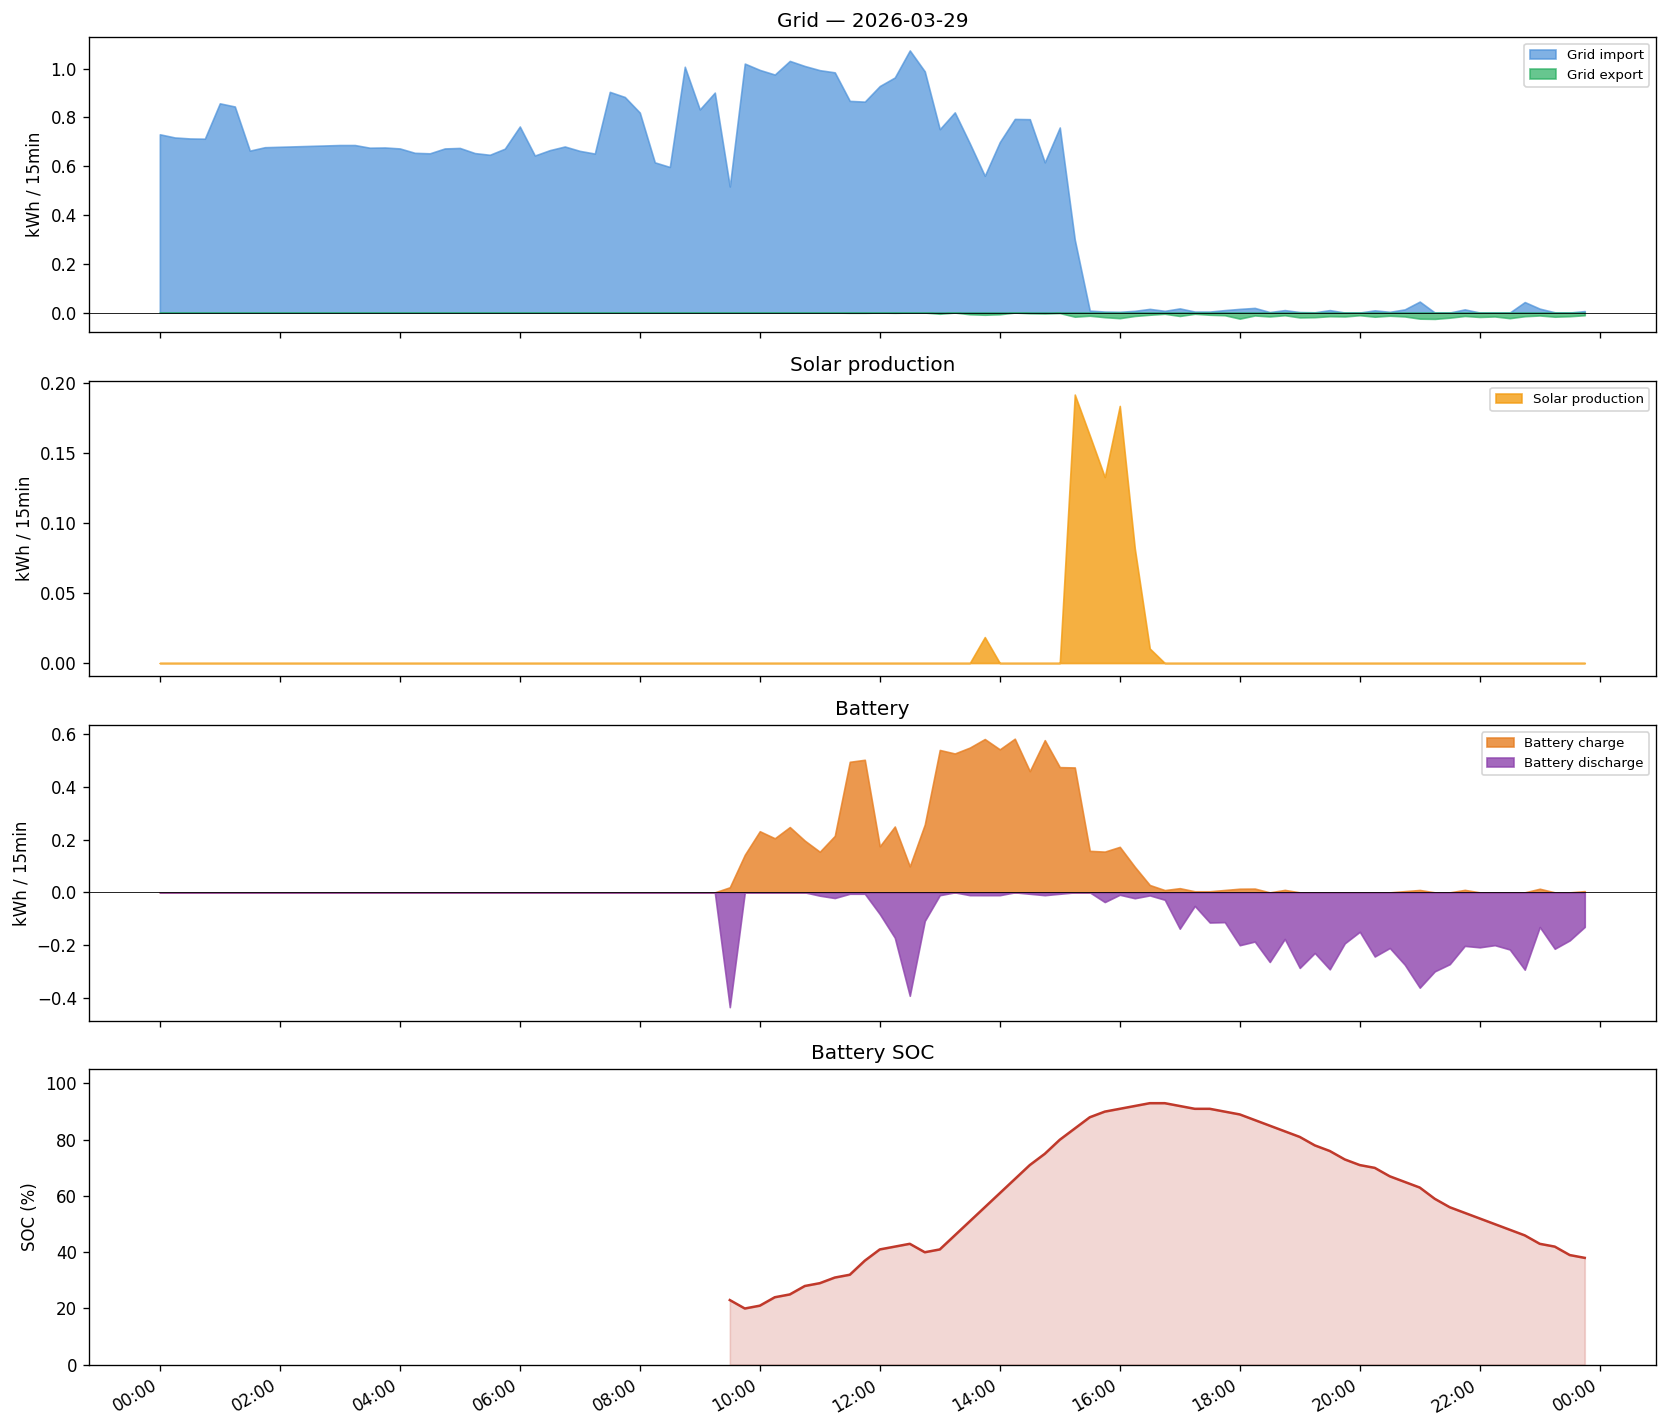

In [176]:
# ── Change DAY and press Shift+Enter to view a different date ──────────────
# 2025-06-15   Summer, solar peak
# 2025-03-31   Spring, max battery month
# 2025-01-20   Winter, high grid import
# 2025-05-20   Solar surplus + injection
# 2025-10-15   Stuck sensor (worst day)
# 2025-04-13   Stuck sensor (2nd worst)
# 2025-12-21   Winter solstice, low solar
# 2026-01-21   Jan 2026 (SOC available)
# 2026-03-29   Apr 2026 (SOC available)
# ────────────────────────────────────────────────────────────────────────────
DAY = "2026-03-29"

plt.close("all")
day = df.loc[DAY].copy()
has_soc = day["soc_begin"].notna().any()
n = 4 if has_soc else 3

fig, axes = plt.subplots(n, 1, figsize=(14, 3 * n), sharex=True)

ax = axes[0]
ax.fill_between(day.index, day["afname_kwh"],    alpha=0.7, color="#4a90d9", label="Grid import")
ax.fill_between(day.index, -day["injectie_kwh"], alpha=0.7, color="#27ae60", label="Grid export")
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("kWh / 15min"); ax.set_title(f"Grid — {DAY}")
ax.legend(fontsize=8, loc="upper right")

ax = axes[1]
ax.fill_between(day.index, day["sl_productie_kwh"], alpha=0.8, color="#f39c12", label="Solar production")
ax.set_ylabel("kWh / 15min"); ax.set_title("Solar production")
ax.legend(fontsize=8, loc="upper right")

ax = axes[2]
ax.fill_between(day.index,  day["bat_laden_kwh_kw"],    alpha=0.8, color="#e67e22", label="Battery charge")
ax.fill_between(day.index, -day["bat_ontladen_kwh_kw"], alpha=0.8, color="#8e44ad", label="Battery discharge")
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("kWh / 15min")
ax.set_title("Battery  (SOC not logged — only 18 days total in dataset)" if not has_soc else "Battery")
ax.legend(fontsize=8, loc="upper right")

if has_soc:
    ax = axes[3]
    ax.plot(day.index, day["soc_begin"], color="#c0392b", lw=1.5)
    ax.fill_between(day.index, day["soc_begin"], alpha=0.2, color="#c0392b")
    ax.set_ylabel("SOC (%)"); ax.set_ylim(0, 105); ax.set_title("Battery SOC")

axes[n-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[n-1].xaxis.set_major_locator(mdates.HourLocator(interval=2))
fig.autofmt_xdate(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 9. Annual energy summary

In [177]:
yearly = hourly[["afname_kwh","injectie_kwh","bat_laden_kwh_kw",
                  "bat_ontladen_kwh_kw","verbruik_kwh"]].resample("YE").sum(min_count=1)
yearly.index = yearly.index.year

print("Annual energy totals (kWh):")
print(yearly.round(0).to_string())

months_2024 = 2   # Nov + Dec
months_2026 = 4   # Jan - Apr

print("\nEstimated full-year values (scaled from partial data):")
for year, n_months in [(2024, months_2024), (2026, months_2026)]:
    if year in yearly.index:
        row = yearly.loc[year]
        scale = 12 / n_months
        print(f"  {year} (x{scale:.1f} from {n_months} months): "
              f"import={row['afname_kwh']*scale:.0f}  "
              f"injection={row['injectie_kwh']*scale:.0f}  "
              f"consumption={row['verbruik_kwh']*scale:.0f} kWh")
if 2025 in yearly.index:
    row = yearly.loc[2025]
    print(f"  2025 (full year):  import={row['afname_kwh']:.0f}  "
          f"injection={row['injectie_kwh']:.0f}  "
          f"consumption={row['verbruik_kwh']:.0f} kWh")


Annual energy totals (kWh):
          afname_kwh  injectie_kwh  bat_laden_kwh_kw  bat_ontladen_kwh_kw  verbruik_kwh
kwartier                                                                               
2024          1310.0          11.0             331.0                306.0        1150.0
2025          7608.0         224.0            1497.0               1397.0        5902.0
2026          2637.0          24.0             186.0                158.0        1862.0

Estimated full-year values (scaled from partial data):
  2024 (x6.0 from 2 months): import=7859  injection=67  consumption=6902 kWh
  2026 (x3.0 from 4 months): import=7912  injection=73  consumption=5585 kWh
  2025 (full year):  import=7608  injection=224  consumption=5902 kWh


## 10. Join with dynamic EPEX prices

`epex_kwartieren.csv` contains EPEX day-ahead prices per 15-min in **UTC**.  
`overall_verrijkt.csv` uses **Belgian local time** (CET = UTC+1 in winter, CEST = UTC+2 in summer).  
We convert EPEX UTC → local time before joining.


In [178]:
EPEX_FILE = os.path.join("..", "..", "Data", "real_load", "intermediate results", "epex_kwartieren.csv")

epex = pd.read_csv(EPEX_FILE, parse_dates=["tijdstip_utc"])
epex = epex.set_index("tijdstip_utc")
epex.index = epex.index.tz_localize("UTC").tz_convert("Europe/Brussels").tz_localize(None)
epex.index.name = "kwartier"
epex["price_eur_kwh"] = epex["price_eur_mwh"] / 1000

print(f"EPEX rows: {len(epex):,}")
print(f"Date range: {epex.index.min()} → {epex.index.max()}")
print(epex.head(3))


EPEX rows: 69,984
Date range: 2024-04-11 00:00:00 → 2026-04-09 23:45:00
                     price_eur_mwh  price_eur_kwh
kwartier                                         
2024-04-11 00:00:00      75.081574       0.075082
2024-04-11 00:15:00      60.976653       0.060977
2024-04-11 00:30:00      48.827540       0.048828


In [179]:
combined = df.join(epex[["price_eur_kwh"]], how="inner")

print(f"Combined rows: {len(combined):,}")
print(f"Missing price: {combined['price_eur_kwh'].isna().sum()} rows")

combined["cost_dynamic"] = combined["afname_kwh"] * combined["price_eur_kwh"] \
                          - combined["injectie_kwh"] * combined["price_eur_kwh"]

h = combined[["afname_kwh","injectie_kwh","verbruik_kwh",
              "bat_laden_kwh_kw","bat_ontladen_kwh_kw",
              "cost_dynamic"]].resample("h").sum(min_count=1)
h["soc_begin"]     = combined["soc_begin"].resample("h").mean()
h["price_eur_kwh"] = combined["price_eur_kwh"].resample("h").mean()
h["hour"]  = h.index.hour
h["month"] = pd.DatetimeIndex(h.index).month

print(f"Hourly rows: {len(h):,}")
print(f"Price range: {h['price_eur_kwh'].min():.4f} → {h['price_eur_kwh'].max():.4f} EUR/kWh")


Combined rows: 50,112
Missing price: 0 rows
Hourly rows: 12,528
Price range: -0.4623 → 0.5655 EUR/kWh


## 11. Actual electricity cost — monthly overview (dag/nacht tariff)

The household pays a two-rate tariff:
- **Dag**: 0.30 EUR/kWh
- **Nacht**: 0.22 EUR/kWh
- **Injection** (solar surplus back to grid): 0.0 EUR/kWh (no compensation)

Cost = grid import × tariff − injection × 0 = purely what the household pays per month.

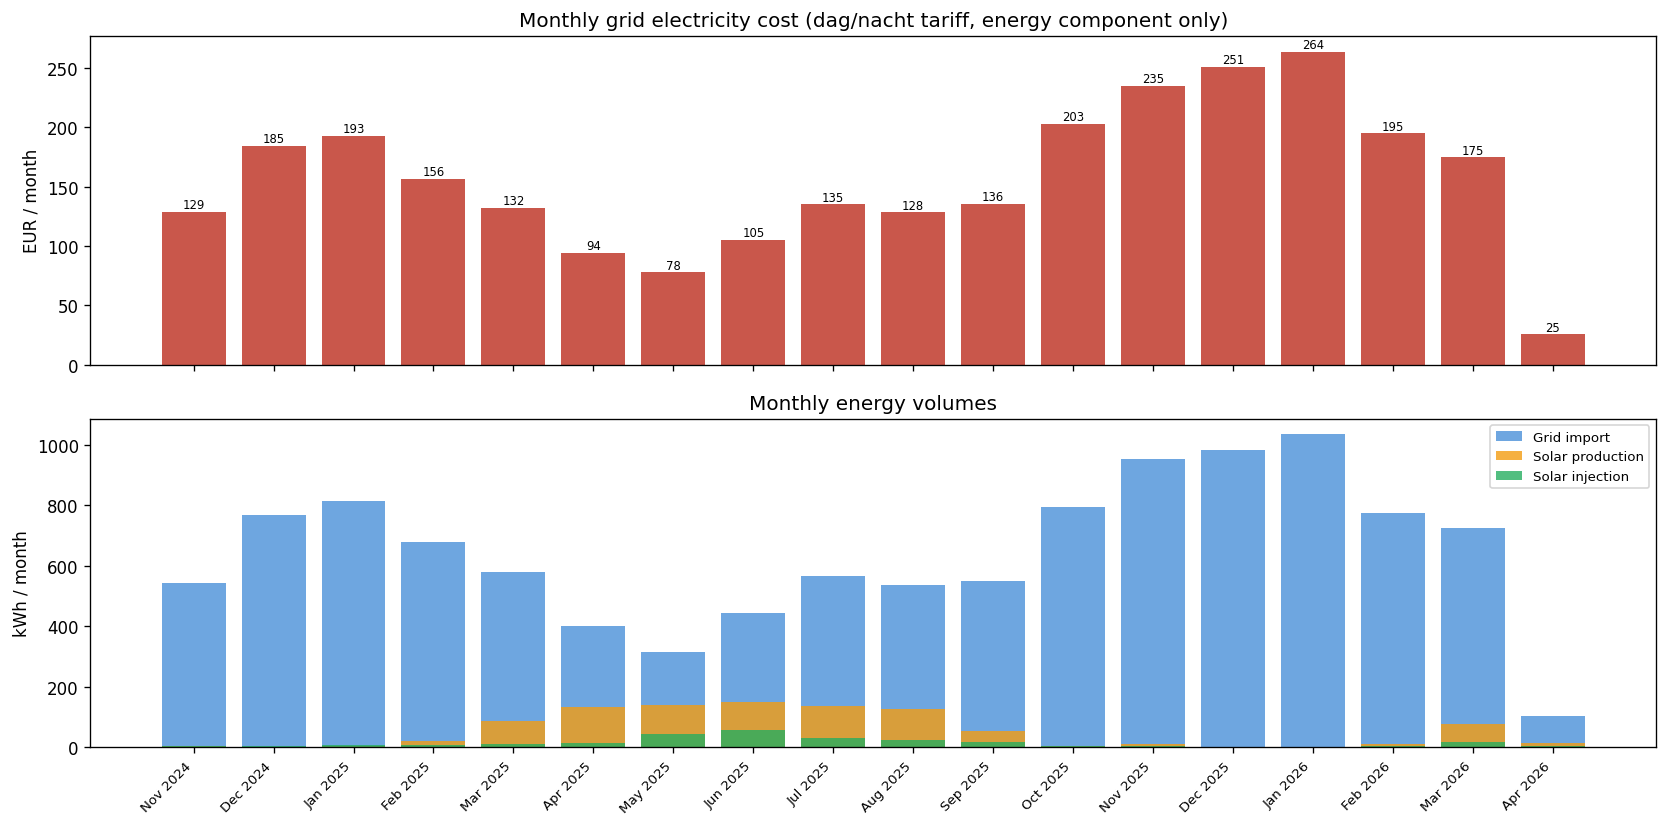

          import_kwh  solar_kwh  inject_kwh  cost_eur
kwartier                                             
Nov 2024       544.0        6.0         6.0    128.64
Dec 2024       766.0        0.0         6.0    184.54
Jan 2025       815.0        4.0         6.0    192.63
Feb 2025       679.0       23.0         8.0    156.41
Mar 2025       579.0       86.0        11.0    132.28
Apr 2025       402.0      134.0        13.0     94.26
May 2025       316.0      141.0        43.0     77.82
Jun 2025       443.0      149.0        58.0    105.34
Jul 2025       566.0      135.0        31.0    135.20
Aug 2025       537.0      127.0        25.0    128.25
Sep 2025       548.0       55.0        17.0    135.67
Oct 2025       792.0        6.0         6.0    202.70
Nov 2025       951.0       10.0         4.0    234.66
Dec 2025       981.0        1.0         2.0    250.93
Jan 2026      1034.0        1.0         1.0    263.58
Feb 2026       775.0       10.0         3.0    194.76
Mar 2026       725.0       7

In [180]:
# Monthly electricity cost at dag/nacht tariff (energy component only)
PRICE_DAG   = 0.30  # EUR/kWh
PRICE_NACHT = 0.22  # EUR/kWh
PRICE_INJ   = 0.00  # EUR/kWh (no compensation for injection)

df["price_dag_nacht"] = df["tarief"].map({"dag": PRICE_DAG, "nacht": PRICE_NACHT})
df["cost_dagnacht"]   = df["afname_kwh"] * df["price_dag_nacht"]

monthly_cost    = df["cost_dagnacht"].resample("ME").sum()
monthly_import  = df["afname_kwh"].resample("ME").sum()
monthly_inject  = df["injectie_kwh"].resample("ME").sum()
monthly_solar   = df["sl_productie_kwh"].resample("ME").sum()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
x = range(len(monthly_cost))
labels = monthly_cost.index.strftime("%b %Y")

ax = axes[0]
ax.bar(x, monthly_cost, color="#c0392b", alpha=0.85)
ax.set_ylabel("EUR / month")
ax.set_title("Monthly grid electricity cost (dag/nacht tariff, energy component only)")
ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
for xi, v in zip(x, monthly_cost):
    ax.text(xi, v + 0.5, f"{v:.0f}", ha="center", va="bottom", fontsize=7)

ax = axes[1]
ax.bar(x, monthly_import, color="#4a90d9", alpha=0.8, label="Grid import")
ax.bar(x, monthly_solar,  color="#f39c12", alpha=0.8, label="Solar production")
ax.bar(x, monthly_inject, color="#27ae60", alpha=0.8, label="Solar injection")
ax.set_ylabel("kWh / month")
ax.set_title("Monthly energy volumes")
ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    "import_kwh":  monthly_import.round(0),
    "solar_kwh":   monthly_solar.round(0),
    "inject_kwh":  monthly_inject.round(0),
    "cost_eur":    monthly_cost.round(2),
})
summary.index = labels
print(summary.to_string())
print(f"\nTotal period cost (dag/nacht, energy only): {monthly_cost.sum():.2f} EUR")
annual_2025 = df.loc['2025', 'cost_dagnacht'].sum()
print(f"Full year 2025: {annual_2025:.2f} EUR")


In [181]:
# Export dataset for LP optimisation
OUT_FILE = os.path.join("..", "..", "Data", "real_load", "Final", "optimization_input.csv")

opt_df = combined[[
    "price_eur_kwh",       # EPEX spot price
    "tarief",              # dag / nacht flag
    "verbruik_kwh",        # household load (LP uses this as load)
    "ev_energie_kwh",      # EV charging (reference only -- not used for LP)
    "afname_kwh",          # actual grid import (Fluvius)
    "injectie_kwh",        # actual grid export (Fluvius)
    "bat_laden_kwh_kw",    # actual battery charge (SOFAR)
    "bat_ontladen_kwh_kw", # actual battery discharge (SOFAR)
]].copy()

opt_df["ev_energie_kwh"] = opt_df["ev_energie_kwh"].fillna(0.0)

# Clip bat_laden to physical limits before solar formula.
# Glitch -0.250 kWh (2025-03-14): impossible negative charge.
# Glitch +2.000 kWh (2025-02-10): impossible; max = 3 kW x 0.25 h = 0.75 kWh.
bat_laden_clipped = opt_df["bat_laden_kwh_kw"].clip(lower=0, upper=0.75)
opt_df["bat_laden_kwh_kw"] = bat_laden_clipped  # write clipped values back before CSV export

# Re-derive solar from energy balance (verbruik only, no EV).
solar_raw = (
    opt_df["verbruik_kwh"] + opt_df["injectie_kwh"]
    + bat_laden_clipped - opt_df["bat_ontladen_kwh_kw"]
    - opt_df["afname_kwh"]
)
solar_clipped = solar_raw.clip(lower=0)

# Zero out solar where irradiance is 0 (night / fully overcast).
# Prevents meter artefacts and logger glitches from creating fake nighttime solar.
solar_clipped = solar_clipped.where(combined["weer_poa_w_m2"] > 0, 0.0)

opt_df["sl_productie_kwh"] = solar_clipped.where(solar_clipped > 0.001, 0.0)

opt_df.index.name = "kwartier"
opt_df = opt_df.dropna(subset=["price_eur_kwh"])

opt_df.to_csv(OUT_FILE)
print("Saved:", OUT_FILE)
print(f"Rows: {len(opt_df):,}")
print(f"sl_productie 2025: {opt_df.loc['2025','sl_productie_kwh'].sum():.0f} kWh")

# Sanity: no solar when irradiance is 0
night_mask = opt_df.index.hour.isin(range(22, 24)) | opt_df.index.hour.isin(range(0, 6))
night_solar = opt_df.loc[night_mask, "sl_productie_kwh"]
print(f"Night slots with solar > 0: {(night_solar > 0.001).sum()}  (was 392 before fix)")
no_irr = combined["weer_poa_w_m2"].reindex(opt_df.index).fillna(0) == 0
fake_solar = opt_df.loc[no_irr, "sl_productie_kwh"]
print(f"Solar when irradiance=0: {(fake_solar > 0.001).sum()}  (should be 0)")


Saved: ..\..\Data\real_load\Final\optimization_input.csv
Rows: 50,112
sl_productie 2025: 871 kWh
Night slots with solar > 0: 0  (was 392 before fix)
Solar when irradiance=0: 0  (should be 0)


---
## 12. EDA Conclusions — data readiness for LP optimisation

### Data quality
| Check | Result |
|---|---|
| Period | Nov 2024 – Apr 2026 (17 months, 50 104 rows at 15-min) |
| Missing slots | 0 — no gaps in grid / battery / solar columns |
| SOFAR freeze events | 89 periods on 56 days — **no correction** (inverter delivered 0 energy, formula gives 0, correct for LP) |
| `bat_laden` glitches | 2 logger errors fixed: −0.250 kWh on 2025-03-14, +2.000 kWh on 2025-02-10 — clipped to [0, 0.75] |
| Solar formula | `solar = verbruik + injectie + bat_laden_clipped − bat_ontladen − afname`, clip ≥ 0 |
| Nighttime solar | Zeroed with irradiance mask (`weer_poa_w_m2 > 0`) — validated in §14b |
| `injectie_kwh` source | Verified = Fluvius (diff = 0 across all rows) — formula is correct |

### Annual energy balance (2025 full year)

| Flow | kWh | Direction |
|---|---|---|
| Grid import (`afname`) | **7 608** | from grid |
| Grid injection (`injectie`) | 224 | to grid |
| Household consumption (`verbruik`, excl. EV) | 5 902 | load |
| EV charging (`ev_energie`) | 2 466 | load |
| **Total consumption** | **8 368** | all loads |
| Battery charged (`bat_laden`) | 1 497 | into battery |
| Battery discharged (`bat_ontladen`) | 1 397 | from battery |
| Net battery absorption | 100 | stored over year |

### Solar production — two estimates

Solar production is estimated from the AC energy balance across **5 independent meters**
(Fluvius smart meter, SOFAR inverter, OwnDevice, EV charger app, irradiance sensor).
Total uncertainty: **~213 kWh/year** (20% of estimated solar, 2.5% of total consumption).
Main sources: EV session aggregation and inter-meter calibration differences.

| Method | Solar total | Self-consumed | Injected | Self-consumption rate |
|---|---|---|---|---|
| **Formula** (`sl_productie_kwh`, §5) | **871 kWh** | **647 kWh** | 224 kWh | **74%** |
| **Energy balance** (Kirchhoff with EV) | ~1 084 kWh | ~860 kWh | 224 kWh | ~79% |
| Difference (uncertainty) | ~213 kWh | ~213 kWh | — | ~5 pp |

**Formula** (`sl_productie_kwh`): derived per 15-min slot, clipped ≥ 0.
Represents solar actually **delivered to the AC bus** — the correct input for LP optimisation.
Known underestimation sources:
- ~18 kWh/year from EV daytime charging (EV is in `afname` but not in `verbruik`)
- ~195 kWh/year from inter-meter calibration drift and EV session timing (lump-sum per session, not 15-min)

**Energy balance** (Kirchhoff): closes the full annual balance including EV.
Gives a better estimate than the formula by including EV energy in the balance.
Like the formula, it does not account for SOFAR freeze losses — during a freeze,
afname rises and both estimates correctly give solar = 0 (nothing was delivered).

**For LP optimisation, the formula value (871 kWh / 647 kWh self-consumed) is used.**
The 2.5% uncertainty relative to total consumption is within acceptable limits
for a 5-meter residential monitoring system.

### Tariff context
The household is on a **dag/nacht two-rate contract** (not a dynamic EPEX tariff):
- **Dag**: 0.30 EUR/kWh (weekdays 07:00–22:00)
- **Nacht**: 0.22 EUR/kWh (nights + weekends)
- **Injection**: 0.0 EUR/kWh (no compensation for solar surplus)

EPEX prices are included in `optimization_input.csv` solely for LP **comparison** scenarios — not the household's actual contract.

### Battery behaviour (SOFAR ME3000SP, BYD LFP 5 kWh / 3 kW)
| Finding | Implication |
|---|---|
| Charges at nacht (00–06h), discharges at dag | SOFAR follows dag/nacht tariff — good real-world baseline |
| Solar surplus charging (11–17h) | Correct: free energy, not a tariff violation |
| Simultaneous charge + discharge observed | Inverter inefficiency — LP forbids this with `binary=True` |
| SOC logged only 18 days | Not needed for LP — `S_init` is a free parameter |
| EFC: ~0.39/day → ~42-year cycle lifetime | Calendar aging dominates before cycle aging |

### Data inputs confirmed for LP optimisation
| LP input | Source column | Notes |
|---|---|---|
| `load` (kWh/slot) | `verbruik_kwh` | 100% coverage |
| `solar` (kWh/slot) | `sl_productie_kwh` | bat_laden clipped + irradiance masked |
| `prices` — dag/nacht | `tarief` mapped to 0.30/0.22 EUR/kWh | **primary scenario** |
| `prices` — dynamic | `price_eur_kwh` + 0.17 markup | comparison scenario only |
| Battery capacity | S_max = 5.0 kWh, P_max = 3 kW (0.75 kWh/slot) | hardware specs |
| Efficiency | η_c = η_d = 0.97 | round-trip ~94% |

**Next step:** run `03_optimization_solar.ipynb` to compare LP-optimised schedule against real SOFAR behaviour on the dag/nacht tariff.